<div align="center">

# Automated ECG Arrhythmia Classification with 1D Convolutional Neural Networks

### A Reproducible End-to-End Research Study on the MIT-BIH Arrhythmia Corpus

**Task:** 5-class morphological heartbeat categorization &nbsp;|&nbsp;
**Data:** `shayanfazeli/heartbeat` (Kaggle) &nbsp;|&nbsp;
**Hardware target:** Google Colab · NVIDIA T4 (15 GB VRAM) · 12.7 GB RAM · 112 GB disk

</div>

---

### Abstract

Cardiac arrhythmias are among the most common manifestations of cardiovascular disease, the
leading cause of death worldwide. Manual inspection of long-duration electrocardiogram (ECG)
recordings by cardiologists is slow, expensive and subject to inter-observer variability. In this
study we build a complete, reproducible pipeline that classifies individual, pre-segmented
heartbeats from the **MIT-BIH Arrhythmia Database** into five AAMI-aligned morphological
categories. We (i) characterise the severe class imbalance of the corpus, (ii) correct it with a
hybrid down/up-sampling scheme combined with physiologically plausible signal augmentation,
(iii) establish a classical **Random Forest** benchmark on the raw 187-sample feature vector, and
(iv) train a regularised **1D Convolutional Neural Network** that learns morphology directly from
the waveform. All models are evaluated on the *untouched, naturally imbalanced* official test
split using macro-averaged Precision/Recall/F1, per-class confusion analysis and a head-to-head
comparative study.

---

### Notebook roadmap

| § | Section | Type |
|:--|:--------|:-----|
| 0 | Environment setup, reproducibility & hardware audit | Code |
| 1 | Introduction & problem definition | Markdown |
| 2 | Data acquisition via `kagglehub` | Code |
| 3 | Exploratory Data Analysis (shapes, dtypes, imbalance, morphology templates) | Code + Markdown |
| 4 | Preprocessing, resampling & 3D tensor reshaping | Code + Markdown |
| 5 | Baseline classical model (Random Forest) | Code + Markdown |
| 6 | Deep learning core model (1D CNN) | Code + Markdown |
| 7 | Evaluation & comparative analysis | Code + Markdown |
| 8 | Conclusion & future directions | Markdown |
| 9 | References | Markdown |

> **Execution note.** Run the cells top-to-bottom. On a T4 the full notebook
> (data download + Random Forest + 40-epoch CNN budget with early stopping) completes in
> roughly **12-20 minutes**. Set `Runtime → Change runtime type → T4 GPU` before starting.


## 0. Environment Setup, Reproducibility & Hardware Audit

We pin the random state of Python, NumPy and TensorFlow so that every reported number is
reproducible, and we probe the runtime to confirm that a GPU is actually attached. Enabling
**memory growth** on the physical GPU prevents TensorFlow from pre-allocating the entire 15 GB of
T4 VRAM, which keeps head-room for the plotting stack and the scikit-learn baseline that live in
the same process.


In [1]:
# ============================================================================
# 0.1 - Dependency installation
# ----------------------------------------------------------------------------
# Colab already ships TensorFlow, scikit-learn, pandas and matplotlib.
# `kagglehub` is the only mandatory extra dependency for programmatic data access.
# The `-q` flag keeps the notebook output clean.
# ============================================================================
!pip install -q --upgrade kagglehub

In [2]:
# ============================================================================
# 0.2 - Imports, global configuration and deterministic seeding
# ============================================================================
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils import resample, shuffle

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Global experiment configuration (single source of truth)
# ---------------------------------------------------------------------------
SEED = 42                 # Master random seed
N_TIMESTEPS = 187         # Samples per heartbeat window in this corpus
N_CHANNELS = 1            # Single-lead (lead II) recording -> 1 channel
N_CLASSES = 5             # N, S, V, F, Q
TARGET_PER_CLASS = 20_000  # Post-resampling size of every training class
VAL_SPLIT = 0.10          # Fraction of the balanced train set held out for validation
BATCH_SIZE = 128          # Comfortable for a T4: ~0.1 GB of activations for this model
EPOCHS = 40               # Upper bound; EarlyStopping almost always halts sooner
LEARNING_RATE = 1e-3

CLASS_LABELS = ["N", "S", "V", "F", "Q"]
CLASS_NAMES = [
    "N - Normal",
    "S - Supraventricular ectopic",
    "V - Ventricular ectopic",
    "F - Fusion",
    "Q - Unknown / paced",
]
CLASS_PALETTE = ["#2E86AB", "#F6AE2D", "#E4572E", "#8E6C8A", "#3B7A57"]


def set_global_seed(seed: int = SEED) -> None:
    """Seed every RNG that can influence the results of this notebook."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_global_seed(SEED)

# ---------------------------------------------------------------------------
# Plotting defaults - consistent, publication-friendly styling
# ---------------------------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.size": 10,
    "legend.frameon": False,
})

print(f"NumPy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"TensorFlow  : {tf.__version__}")
print(f"Keras       : {keras.__version__}")

NumPy       : 2.0.2
pandas      : 2.2.3
TensorFlow  : 2.20.0
Keras       : 3.13.2


In [3]:
# ============================================================================
# 0.3 - Hardware audit: confirm the T4 is visible and cap VRAM pre-allocation
# ============================================================================
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        # Grow VRAM on demand instead of reserving all 15 GB up-front.
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"[OK] {len(gpus)} GPU device(s) detected -> {gpus}")
else:
    print("[WARN] No GPU detected. Enable Runtime > Change runtime type > T4 GPU.")
    print("       The notebook still runs on CPU, but ~8-10x slower.")

# Human-readable device summary (nvidia-smi is available on Colab GPU runtimes).
!nvidia-smi --query-gpu=name,memory.total,memory.used,driver_version \
            --format=csv,noheader 2>/dev/null || echo "nvidia-smi unavailable (CPU runtime)"

[OK] 1 GPU device(s) detected -> [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Tesla T4, 15360 MiB, 3 MiB, 580.82.07


## 1. Introduction & Problem Definition

### 1.1 Clinical motivation

Cardiovascular disease accounts for roughly **one in three deaths globally**, and a substantial
share of sudden cardiac deaths is preceded by an *arrhythmia* — a disturbance of the heart's
electrical conduction system. The electrocardiogram (ECG) is the primary, non-invasive, low-cost
modality for observing that electrical activity. Modern ambulatory monitoring (Holter monitors,
patch recorders, smartwatches) routinely produces **24 hours to 14 days** of continuous
single-lead signal, which is on the order of **100 000 – 1 500 000 heartbeats per patient**.

Manual, beat-by-beat annotation of such recordings is:

* **Labour intensive** — a cardiologist may need several hours per 24 h recording;
* **Error prone** — clinically significant ectopic beats are rare events buried in a sea of
  normal beats, and fatigue-driven misses are well documented;
* **Inconsistent** — reported inter-observer agreement for beat typing is far from perfect,
  which directly degrades downstream diagnostic decisions.

An automated classifier that flags abnormal morphologies with **high recall on the minority
classes** therefore acts as a triage layer: it can compress hours of expert review into minutes
by surfacing only the beats that matter, and it can run continuously on wearable-class hardware.

### 1.2 The five morphological categories

The dataset follows the **AAMI EC57** convention, which collapses the ~15 fine-grained MIT-BIH
annotation symbols into five clinically actionable super-classes:

| Code | Class | Underlying MIT-BIH annotations | Clinical meaning |
|:----:|:------|:-------------------------------|:-----------------|
| **0** | **N** — Normal | Normal beat, left/right bundle branch block, atrial escape, nodal escape | Sinus-origin or benign conduction beats |
| **1** | **S** — Supraventricular ectopic | Atrial premature, aberrated atrial premature, nodal premature, supraventricular premature | Early beat originating above the ventricles; associated with atrial fibrillation risk |
| **2** | **V** — Ventricular ectopic | Premature ventricular contraction, ventricular escape | Wide, bizarre QRS; frequent PVCs can precede ventricular tachycardia |
| **3** | **F** — Fusion | Fusion of ventricular and normal beat | Simultaneous activation from two foci; morphologically ambiguous |
| **4** | **Q** — Unknown / paced | Paced beat, fusion of paced and normal, unclassifiable | Device-driven or non-interpretable beats |

### 1.3 Signal representation

Each row of the CSV files is a **single, pre-segmented and pre-processed heartbeat**:

* the raw MIT-BIH signal was band-pass filtered and **resampled to 125 Hz**;
* beats were extracted around detected R-peaks over a fixed window and
  **zero-padded to a common length of 187 samples** (≈ 1.5 s of signal);
* amplitudes were **min-max normalised to $[0, 1]$**, so no additional scaling is required;
* column index **187** (the 188th column) holds the integer class label $y \in \{0,1,2,3,4\}$.

Formally, we learn a mapping

$$ f_\theta : \mathbb{R}^{187 \times 1} \rightarrow \Delta^4, \qquad
   \hat{y} = \arg\max_{c} \; f_\theta(\mathbf{x})_c $$

where $\Delta^4$ is the 4-simplex of class probabilities produced by a softmax layer, and
$\theta$ is optimised by minimising the categorical cross-entropy

$$ \mathcal{L}(\theta) = -\frac{1}{N}\sum_{i=1}^{N}\sum_{c=0}^{4}
   y_{i,c}\,\log f_\theta(\mathbf{x}_i)_c . $$

### 1.4 Research questions

1. **RQ1** — How severe is the class imbalance, and does a resampling strategy measurably improve
   minority-class recall relative to training on the raw distribution?
2. **RQ2** — Can a classical ensemble (Random Forest) operating on the raw 187-dimensional vector
   already solve the task, i.e. is deep learning warranted?
3. **RQ3** — Does a 1D CNN, which exploits the *temporal locality* of QRS morphology through
   weight sharing, outperform the order-agnostic baseline — particularly on the rare
   **S** and **F** classes?

### 1.5 Evaluation protocol

> **Golden rule of this study:** resampling is applied **only to the training split**.
> The official `mitbih_test.csv` is left in its natural, imbalanced state so that reported
> metrics reflect deployment conditions. Because accuracy is misleading under an 82 % majority
> prior, the **macro-averaged F1-score** is our headline metric.


## 2. Data Acquisition — Programmatic Download with `kagglehub`

`kagglehub` resolves the dataset slug, downloads the archive to the Colab cache
(`~/.cache/kagglehub/...`), extracts it and returns the local directory path. This removes any
dependency on manual uploads and makes the notebook fully reproducible on a fresh runtime.

If the runtime prompts for credentials, authenticate once with a Kaggle API token
(`Account → Create New Token` → upload `kaggle.json`, or call `kagglehub.login()`).

**Expected footprint:** ~105 MB extracted — negligible against the 112 GB disk budget.


In [4]:
# ============================================================================
# 2.1 - Download the dataset (mandatory kagglehub method)
# ============================================================================
import kagglehub

path = kagglehub.dataset_download("shayanfazeli/heartbeat")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heartbeat' dataset.
Path to dataset files: /kaggle/input/heartbeat


In [5]:
# ============================================================================
# 2.2 - Inspect the downloaded directory and resolve the two CSV files
# ============================================================================
from pathlib import Path

DATA_DIR = Path(path)

print("Files provided by the dataset:")
for file_path in sorted(DATA_DIR.iterdir()):
    size_mb = file_path.stat().st_size / 1024 ** 2
    print(f"  - {file_path.name:<28} {size_mb:>8.2f} MB")

TRAIN_CSV = DATA_DIR / "mitbih_train.csv"
TEST_CSV = DATA_DIR / "mitbih_test.csv"

# Fail fast with an explicit message instead of an opaque pandas error later on.
assert TRAIN_CSV.exists(), f"Missing training file at {TRAIN_CSV}"
assert TEST_CSV.exists(), f"Missing test file at {TEST_CSV}"
print("\n[OK] Both MIT-BIH CSV files resolved.")

Files provided by the dataset:
  - mitbih_test.csv                 98.13 MB
  - mitbih_train.csv               392.44 MB
  - ptbdb_abnormal.csv              47.09 MB
  - ptbdb_normal.csv                18.14 MB

[OK] Both MIT-BIH CSV files resolved.


## 3. Exploratory Data Analysis

The CSV files are **header-less**: every row is `187 float32 signal samples + 1 label`. We load
them with `header=None` and immediately cast the signal block to `float32` — this halves memory
versus the pandas default `float64` and matches the dtype TensorFlow expects, avoiding a silent
copy at training time.

Memory arithmetic (well inside the 12.7 GB RAM budget):

$$ 87\,554 \times 188 \times 4\ \text{bytes} \approx 65.8\ \text{MB (train)}, \qquad
   21\,892 \times 188 \times 4\ \text{bytes} \approx 16.5\ \text{MB (test)} $$


In [6]:
# ============================================================================
# 3.1 - Load the CSVs
# ----------------------------------------------------------------------------
# header=None  : the files carry no column names.
# dtype=float32: halves RAM vs float64 and matches the TF compute dtype.
# The label lives in the last column (index 187) and is cast back to int8 below.
# ============================================================================
train_df = pd.read_csv(TRAIN_CSV, header=None, dtype=np.float32)
test_df = pd.read_csv(TEST_CSV, header=None, dtype=np.float32)

# Name the columns: t_000 ... t_186 for the signal, "label" for the target.
signal_cols = [f"t_{i:03d}" for i in range(N_TIMESTEPS)]
train_df.columns = signal_cols + ["label"]
test_df.columns = signal_cols + ["label"]

# The target is categorical -> store it compactly as int8 (values 0..4).
train_df["label"] = train_df["label"].astype(np.int8)
test_df["label"] = test_df["label"].astype(np.int8)

print(f"Train shape : {train_df.shape}   (expected 87554 x 188)")
print(f"Test  shape : {test_df.shape}   (expected 21892 x 188)")
print(f"Train RAM   : {train_df.memory_usage(deep=True).sum() / 1024 ** 2:.1f} MB")
print(f"Test  RAM   : {test_df.memory_usage(deep=True).sum() / 1024 ** 2:.1f} MB")

train_df.head()

Train shape : (87554, 188)   (expected 87554 x 188)
Test  shape : (21892, 188)   (expected 21892 x 188)
Train RAM   : 62.5 MB
Test  RAM   : 15.6 MB


,t_000,t_001,t_002,t_003,t_004,t_005,t_006,t_007,t_008,t_009,...,t_178,t_179,t_180,t_181,t_182,t_183,t_184,t_185,t_186,label
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [7]:
# ============================================================================
# 3.2 - Structural integrity checks: dtypes, NaNs, value range, duplicates
# ============================================================================
print("Dtype summary")
print(train_df.dtypes.value_counts().to_string(), "\n")

print(f"Missing values (train) : {int(train_df.isna().sum().sum())}")
print(f"Missing values (test)  : {int(test_df.isna().sum().sum())}\n")

signal_matrix = train_df[signal_cols].to_numpy()
print(f"Signal min / max       : {signal_matrix.min():.4f} / {signal_matrix.max():.4f}")
print("  -> already min-max normalised to [0, 1]; no extra scaling required.\n")

# Fraction of trailing zero-padding, a well-known artefact of the fixed 187-sample window.
zero_fraction = float((signal_matrix == 0.0).mean())
print(f"Exact-zero cells       : {zero_fraction:.2%} (trailing zero-padding)")
print(f"Duplicate rows (train) : {int(train_df.duplicated().sum())}")

# Descriptive statistics for a handful of representative time steps.
train_df[["t_000", "t_020", "t_060", "t_120", "t_186"]].describe().T

Dtype summary
float32    187
int8         1 

Missing values (train) : 0
Missing values (test)  : 0

Signal min / max       : 0.0000 / 1.0000
  -> already min-max normalised to [0, 1]; no extra scaling required.

Exact-zero cells       : 40.85% (trailing zero-padding)
Duplicate rows (train) : 0


,count,mean,std,min,25%,50%,75%,max
t_000,87554.0,0.890360,0.240888,0.0,0.921922,0.991342,1.000000,1.0
t_020,87554.0,0.253749,0.211186,0.0,0.079442,0.194595,0.369980,1.0
t_060,87554.0,0.273436,0.186777,0.0,0.132135,0.237245,0.370607,1.0
t_120,87554.0,0.101637,0.193616,0.0,0.000000,0.000000,0.122399,1.0
t_186,87554.0,0.002807,0.031921,0.0,0.000000,0.000000,0.000000,1.0


In [8]:
# ============================================================================
# 3.3 - Class distribution: quantifying the imbalance
# ============================================================================
train_counts = train_df["label"].value_counts().sort_index()
test_counts = test_df["label"].value_counts().sort_index()

dist = pd.DataFrame({
    "class": CLASS_LABELS,
    "description": CLASS_NAMES,
    "train_n": train_counts.values,
    "train_%": (100 * train_counts / train_counts.sum()).round(2).values,
    "test_n": test_counts.values,
    "test_%": (100 * test_counts / test_counts.sum()).round(2).values,
})
dist["imbalance_ratio_vs_N"] = (train_counts.max() / train_counts).round(1).values

print(dist.to_string(index=False))
print(f"\nWorst-case imbalance ratio : {train_counts.max() / train_counts.min():.1f} : 1")
print(f"Majority-class prior       : {100 * train_counts.max() / train_counts.sum():.2f}% "
      "(a trivial 'always predict N' model reaches this accuracy)")

class                  description  train_n  train_%  test_n  test_%  imbalance_ratio_vs_N
    N                   N - Normal    72471    82.77   18118   82.76                   1.0
    S S - Supraventricular ectopic     2223     2.54     556    2.54                  32.6
    V      V - Ventricular ectopic     5788     6.61    1448    6.61                  12.5
    F                   F - Fusion      641     0.73     162    0.74                 113.1
    Q          Q - Unknown / paced     6431     7.35    1608    7.35                  11.3

Worst-case imbalance ratio : 113.1 : 1
Majority-class prior       : 82.77% (a trivial 'always predict N' model reaches this accuracy)


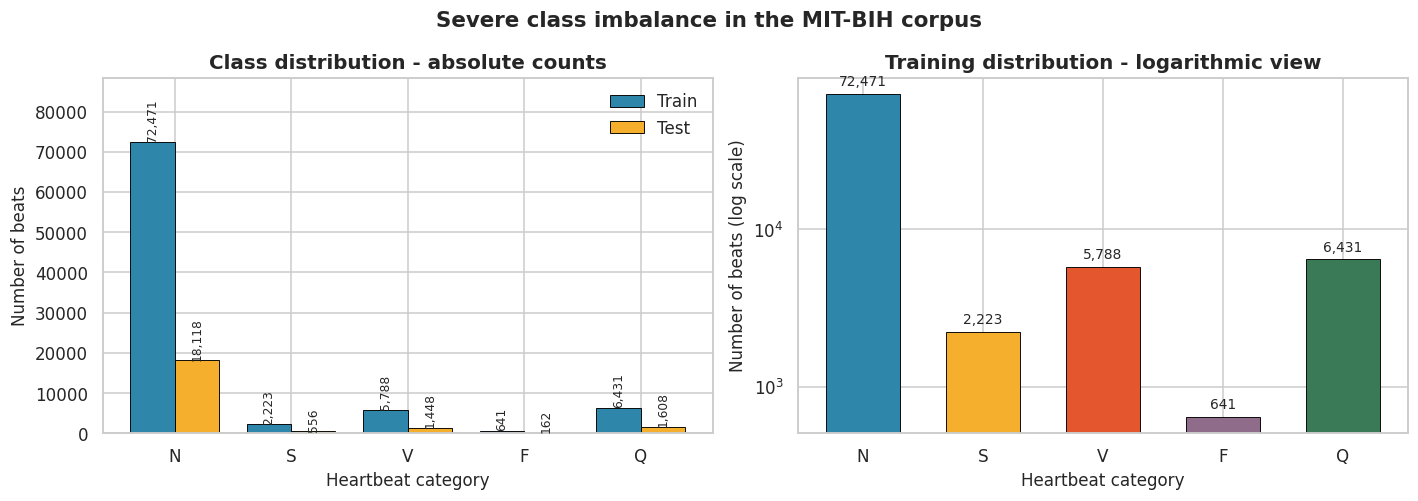

In [9]:
# ============================================================================
# 3.4 - Visualising the imbalance (bar chart, linear + log scale)
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# --- Left: absolute counts, train vs test ---------------------------------
x_pos = np.arange(N_CLASSES)
bar_w = 0.38
axes[0].bar(x_pos - bar_w / 2, train_counts.values, bar_w,
            label="Train", color="#2E86AB", edgecolor="black", linewidth=0.6)
axes[0].bar(x_pos + bar_w / 2, test_counts.values, bar_w,
            label="Test", color="#F6AE2D", edgecolor="black", linewidth=0.6)

for xi, (tr, te) in enumerate(zip(train_counts.values, test_counts.values)):
    axes[0].text(xi - bar_w / 2, tr, f"{tr:,}", ha="center", va="bottom", fontsize=8, rotation=90)
    axes[0].text(xi + bar_w / 2, te, f"{te:,}", ha="center", va="bottom", fontsize=8, rotation=90)

axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(CLASS_LABELS)
axes[0].set_xlabel("Heartbeat category")
axes[0].set_ylabel("Number of beats")
axes[0].set_title("Class distribution - absolute counts")
axes[0].set_ylim(0, train_counts.max() * 1.22)
axes[0].legend()

# --- Right: log scale makes the minority classes legible -------------------
axes[1].bar(x_pos, train_counts.values, 0.62,
            color=CLASS_PALETTE, edgecolor="black", linewidth=0.6)
axes[1].set_yscale("log")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(CLASS_LABELS)
axes[1].set_xlabel("Heartbeat category")
axes[1].set_ylabel("Number of beats (log scale)")
axes[1].set_title("Training distribution - logarithmic view")
for xi, val in enumerate(train_counts.values):
    axes[1].text(xi, val * 1.08, f"{val:,}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Severe class imbalance in the MIT-BIH corpus", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

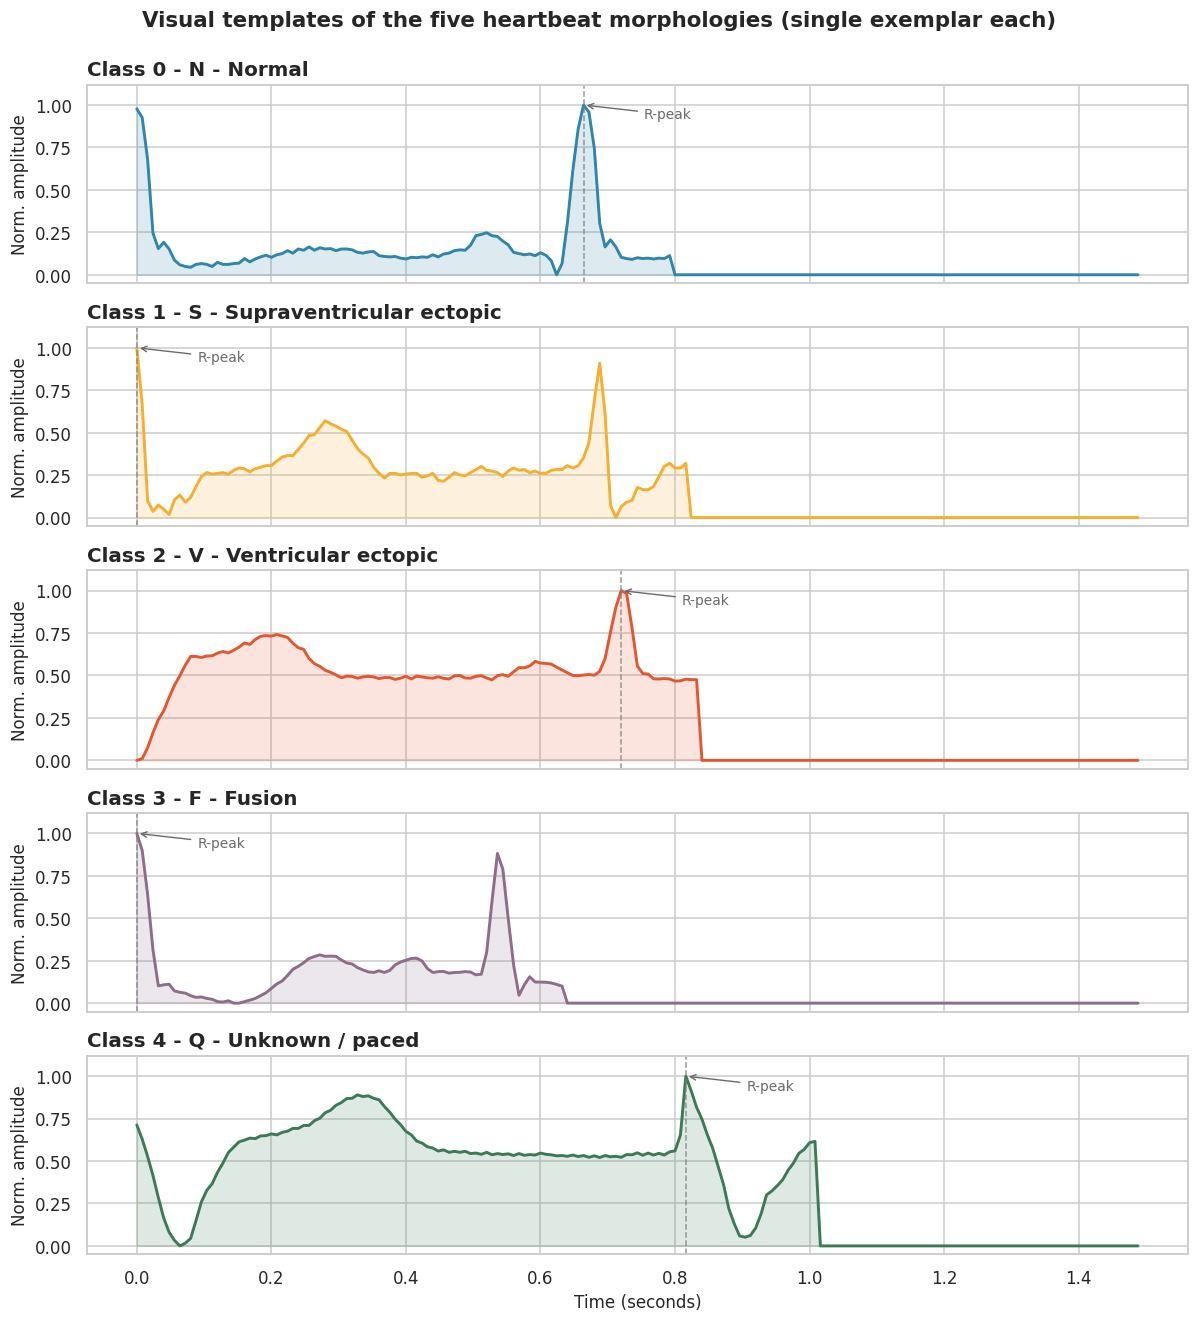

In [10]:
# ============================================================================
# 3.5 - Morphology templates: one representative heartbeat per category
# ----------------------------------------------------------------------------
# Sampling rate is 125 Hz, so the time axis spans 187 / 125 = 1.496 seconds.
# ============================================================================
SAMPLING_RATE_HZ = 125
time_axis = np.arange(N_TIMESTEPS) / SAMPLING_RATE_HZ

fig, axes = plt.subplots(5, 1, figsize=(11, 12), sharex=True)

for class_id, ax in enumerate(axes):
    # Deterministically pick the first available beat of this class.
    beat = train_df[train_df["label"] == class_id][signal_cols].iloc[0].to_numpy()

    ax.plot(time_axis, beat, color=CLASS_PALETTE[class_id], linewidth=1.9)
    ax.fill_between(time_axis, beat, alpha=0.16, color=CLASS_PALETTE[class_id])

    # Mark the R-peak (global maximum) - the anatomical anchor of the window.
    r_idx = int(np.argmax(beat))
    ax.axvline(time_axis[r_idx], color="grey", linestyle="--", linewidth=1.0, alpha=0.8)
    ax.annotate("R-peak", xy=(time_axis[r_idx], beat[r_idx]),
                xytext=(time_axis[r_idx] + 0.09, beat[r_idx] * 0.92),
                fontsize=9, color="dimgrey",
                arrowprops=dict(arrowstyle="->", color="dimgrey", lw=0.9))

    ax.set_title(f"Class {class_id} - {CLASS_NAMES[class_id]}", loc="left")
    ax.set_ylabel("Norm. amplitude")
    ax.set_ylim(-0.05, 1.12)

axes[-1].set_xlabel("Time (seconds)")
fig.suptitle("Visual templates of the five heartbeat morphologies (single exemplar each)",
             fontsize=14, fontweight="bold", y=0.998)
fig.tight_layout()
plt.show()

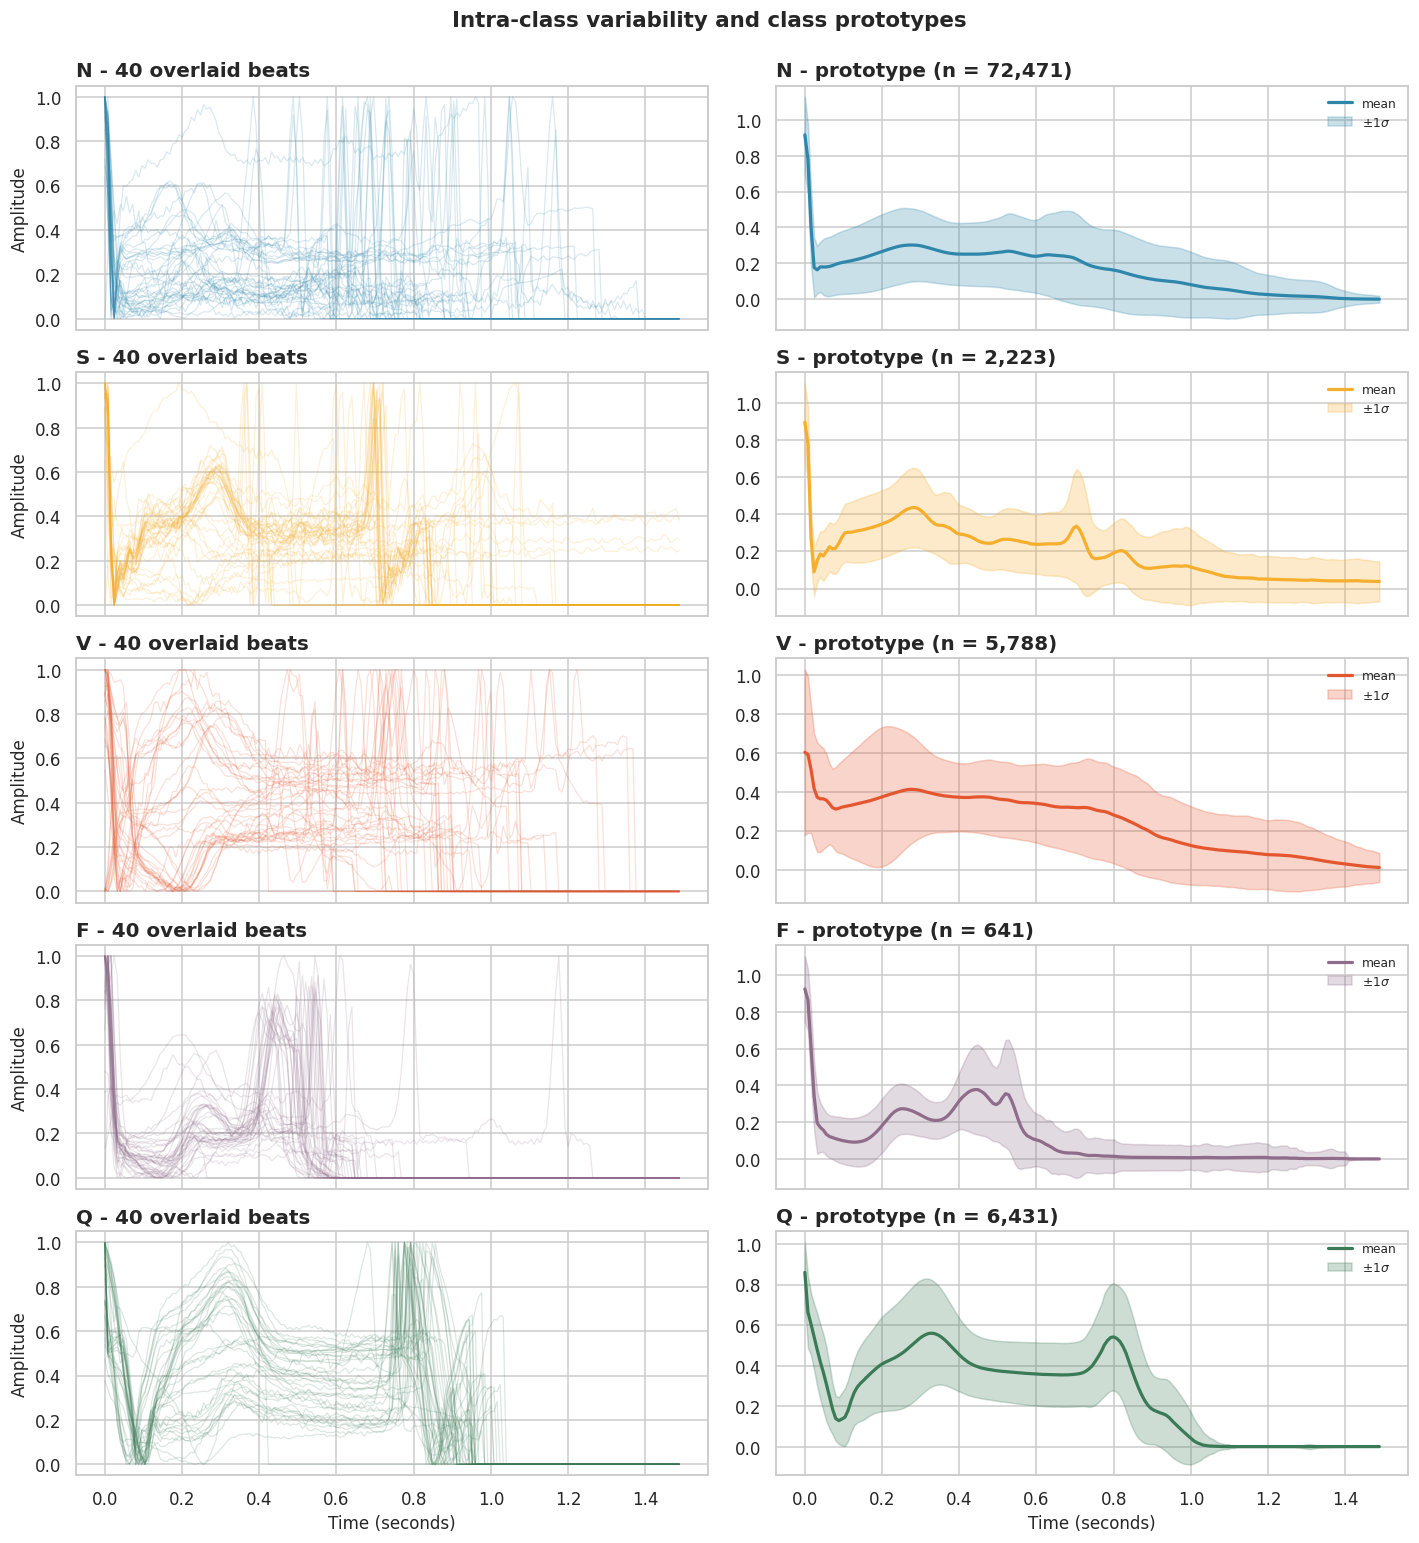

In [11]:
# ============================================================================
# 3.6 - Overlay + mean/std envelope: how consistent is each morphology?
# ----------------------------------------------------------------------------
# Left column : 40 random beats overlaid -> shows intra-class variability.
# Right column: mean waveform +/- 1 standard deviation -> the class "prototype".
# ============================================================================
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(5, 2, figsize=(13, 14), sharex=True)

for class_id in range(N_CLASSES):
    class_signals = train_df.loc[train_df["label"] == class_id, signal_cols].to_numpy()

    # ---- Left: random overlay --------------------------------------------
    n_show = min(40, len(class_signals))
    sample_idx = rng.choice(len(class_signals), size=n_show, replace=False)
    for row in class_signals[sample_idx]:
        axes[class_id, 0].plot(time_axis, row, color=CLASS_PALETTE[class_id],
                               alpha=0.18, linewidth=0.8)
    axes[class_id, 0].set_title(f"{CLASS_LABELS[class_id]} - {n_show} overlaid beats", loc="left")
    axes[class_id, 0].set_ylabel("Amplitude")

    # ---- Right: mean +/- 1 std envelope ----------------------------------
    mu = class_signals.mean(axis=0)
    sigma = class_signals.std(axis=0)
    axes[class_id, 1].plot(time_axis, mu, color=CLASS_PALETTE[class_id], linewidth=2.1,
                           label="mean")
    axes[class_id, 1].fill_between(time_axis, mu - sigma, mu + sigma,
                                   color=CLASS_PALETTE[class_id], alpha=0.25,
                                   label=r"$\pm 1\sigma$")
    axes[class_id, 1].set_title(
        f"{CLASS_LABELS[class_id]} - prototype (n = {len(class_signals):,})", loc="left")
    axes[class_id, 1].legend(loc="upper right", fontsize=8)

axes[-1, 0].set_xlabel("Time (seconds)")
axes[-1, 1].set_xlabel("Time (seconds)")
fig.suptitle("Intra-class variability and class prototypes",
             fontsize=14, fontweight="bold", y=0.999)
fig.tight_layout()
plt.show()

### 3.7 EDA findings

1. **Extreme imbalance.** Class **N** contributes ~82.8 % of the training beats while **F**
   contributes ~0.7 % — an imbalance ratio of roughly **113 : 1**. A degenerate classifier that
   always predicts `N` would already score ~83 % accuracy, which is why accuracy alone is a
   *useless* metric here and macro-F1 is reported instead.
2. **No missing values, no rescaling needed.** The signals are complete and already min-max
   normalised to $[0, 1]$.
3. **Structured zero-padding.** A large share of exact zeros sits at the *end* of the window for
   short beats. Because a 1D CNN slides local kernels, this padding is handled gracefully; a
   flat, order-agnostic model must instead treat those positions as ordinary features.
4. **Morphology is genuinely discriminative.** The prototype plots show a sharp narrow QRS for
   **N**, a widened and inverted complex for **V**, and a template for **F** that sits visually
   *between* N and V — a strong prior that **F** will be the hardest class and the main source of
   confusion.
5. **Train/test distributions match** almost exactly, so the official split is stratified and no
   distribution shift correction is needed.


## 4. Data Preprocessing, Resampling & Tensor Reshaping

### 4.1 Resampling strategy

We apply a **hybrid re-balancing scheme** with a common target of
`TARGET_PER_CLASS = 20 000` beats:

| Class | Original $n$ | Operation | Result |
|:-----:|-------------:|:----------|-------:|
| N | 72 471 | **Down-sample** without replacement | 20 000 |
| S |  2 223 | **Up-sample** with replacement + augmentation | 20 000 |
| V |  5 788 | **Up-sample** with replacement + augmentation | 20 000 |
| F |    641 | **Up-sample** with replacement + augmentation | 20 000 |
| Q |  6 431 | **Up-sample** with replacement + augmentation | 20 000 |

*Why hybrid rather than pure oversampling?* Pure oversampling to 72 471 per class produces a
362 k-row training matrix and needlessly long epochs; pure undersampling to 641 per class throws
away 99 % of the corpus. The hybrid target keeps 100 k balanced rows
(≈ 75 MB as `float32`) — fast on a T4 while retaining a large slice of the majority class.

*Why augmentation?* Naive duplication of the 641 **F** beats replicates them ~31× and invites
memorisation. We therefore perturb every *duplicated* beat with three physiologically plausible
transforms:

* **Amplitude scaling** ($\times\,\mathcal{U}[0.9, 1.1]$) — electrode contact / gain variation;
* **Gaussian jitter** ($\sigma = 0.01$) — baseline sensor noise;
* **Temporal shift** ($\pm 5$ samples = $\pm 40$ ms) — R-peak detection jitter.

Original beats are never modified, and the final signals are re-clipped to $[0, 1]$.

> **Leakage control:** the validation split is carved out of the balanced training pool
> *after* resampling using stratification. We acknowledge that upsampled duplicates of the same
> source beat can straddle the train/val boundary, so validation metrics are mildly optimistic —
> which is exactly why **all headline numbers in § 7 come from the untouched official test set**.

### 4.2 Tensor reshaping

Scikit-learn consumes a 2D design matrix `(samples, features)`, whereas `Conv1D` requires a rank-3
tensor in *channels-last* layout:

$$ \underbrace{(N,\ 187)}_{\text{2D tabular}} \;\longrightarrow\;
   \underbrace{(N,\ 187,\ 1)}_{\text{(samples, time steps, channels)}} $$

The single channel corresponds to the single ECG lead. Keeping the data `float32` in channels-last
order lets cuDNN dispatch its fastest convolution kernels on the T4.


In [12]:
# ============================================================================
# 4.1 - Split features / labels and keep an *unbalanced* copy for reference
# ============================================================================
X_train_raw = train_df[signal_cols].to_numpy(dtype=np.float32)
y_train_raw = train_df["label"].to_numpy(dtype=np.int64)

X_test = test_df[signal_cols].to_numpy(dtype=np.float32)
y_test = test_df["label"].to_numpy(dtype=np.int64)

print(f"X_train_raw : {X_train_raw.shape}  dtype={X_train_raw.dtype}")
print(f"y_train_raw : {y_train_raw.shape}  dtype={y_train_raw.dtype}")
print(f"X_test      : {X_test.shape}  dtype={X_test.dtype}")
print(f"y_test      : {y_test.shape}  dtype={y_test.dtype}")
print(f"\nTest-set class counts (left untouched): "
      f"{dict(zip(*np.unique(y_test, return_counts=True)))}")

X_train_raw : (87554, 187)  dtype=float32
y_train_raw : (87554,)  dtype=int64
X_test      : (21892, 187)  dtype=float32
y_test      : (21892,)  dtype=int64

Test-set class counts (left untouched): {np.int64(0): np.int64(18118), np.int64(1): np.int64(556), np.int64(2): np.int64(1448), np.int64(3): np.int64(162), np.int64(4): np.int64(1608)}


In [13]:
# ============================================================================
# 4.2 - Physiologically plausible augmentation for duplicated minority beats
# ============================================================================
def augment_signals(
    signals: np.ndarray,
    noise_std: float = 0.01,
    scale_range: tuple = (0.90, 1.10),
    max_shift: int = 5,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """Apply light, label-preserving perturbations to a batch of ECG beats.

    Parameters
    ----------
    signals : np.ndarray, shape (n_samples, n_timesteps)
        Min-max normalised heartbeat windows.
    noise_std : float
        Standard deviation of the additive Gaussian sensor noise.
    scale_range : tuple(float, float)
        Multiplicative amplitude-gain range.
    max_shift : int
        Maximum absolute circular shift in samples (125 Hz -> 5 samples = 40 ms).
    rng : np.random.Generator, optional
        Seeded generator for reproducibility.

    Returns
    -------
    np.ndarray, shape (n_samples, n_timesteps), float32
        Augmented copies, re-clipped to the valid [0, 1] amplitude range.
    """
    rng = np.random.default_rng(SEED) if rng is None else rng
    n_samples, n_timesteps = signals.shape

    # 1) Random per-beat amplitude scaling (electrode gain variation).
    scales = rng.uniform(scale_range[0], scale_range[1], size=(n_samples, 1)).astype(np.float32)
    out = signals * scales

    # 2) Additive Gaussian noise (baseline sensor noise).
    out = out + rng.normal(0.0, noise_std, size=out.shape).astype(np.float32)

    # 3) Small circular time shift (R-peak detection jitter).
    shifts = rng.integers(-max_shift, max_shift + 1, size=n_samples)
    row_idx = np.arange(n_timesteps)[None, :]                       # (1, T)
    gather_idx = (row_idx - shifts[:, None]) % n_timesteps          # (N, T)
    out = np.take_along_axis(out, gather_idx, axis=1)

    return np.clip(out, 0.0, 1.0).astype(np.float32)


# Quick static shape sanity check on a tiny slice (cheap, no training involved).
_probe = augment_signals(X_train_raw[:4])
print(f"Augmentation probe -> in {X_train_raw[:4].shape} | out {_probe.shape} | {_probe.dtype}")
assert _probe.shape == (4, N_TIMESTEPS) and _probe.dtype == np.float32

Augmentation probe -> in (4, 187) | out (4, 187) | float32


In [14]:
# ============================================================================
# 4.3 - Hybrid resampling: down-sample the majority, up-sample the minorities
# ============================================================================
def build_balanced_trainset(
    features: np.ndarray,
    labels: np.ndarray,
    target_per_class: int = TARGET_PER_CLASS,
    seed: int = SEED,
) -> tuple:
    """Rebalance a training set to `target_per_class` beats for every class.

    Classes larger than the target are down-sampled without replacement; smaller
    classes are up-sampled with replacement, and every *duplicated* beat receives a
    light augmentation so the model does not simply memorise identical rows.
    """
    rng = np.random.default_rng(seed)
    feature_blocks, label_blocks = [], []

    for class_id in range(N_CLASSES):
        class_features = features[labels == class_id]
        n_available = len(class_features)

        if n_available >= target_per_class:
            # ---- Majority class: random subset, no replacement --------------
            block = resample(
                class_features,
                replace=False,
                n_samples=target_per_class,
                random_state=seed,
            )
        else:
            # ---- Minority class: keep originals, augment the duplicates -----
            n_extra = target_per_class - n_available
            duplicate_idx = rng.integers(0, n_available, size=n_extra)
            duplicates = augment_signals(class_features[duplicate_idx], rng=rng)
            block = np.vstack([class_features, duplicates])

        feature_blocks.append(block.astype(np.float32))
        label_blocks.append(np.full(target_per_class, class_id, dtype=np.int64))

        action = "down-sampled" if n_available >= target_per_class else "up-sampled "
        print(f"  class {class_id} ({CLASS_LABELS[class_id]}): "
              f"{n_available:>6,} -> {target_per_class:>6,}  [{action}]")

    X_bal = np.vstack(feature_blocks)
    y_bal = np.concatenate(label_blocks)
    return shuffle(X_bal, y_bal, random_state=seed)


print("Resampling the training split (test split is never touched):")
X_bal, y_bal = build_balanced_trainset(X_train_raw, y_train_raw)

print(f"\nBalanced training matrix : {X_bal.shape}  ({X_bal.nbytes / 1024 ** 2:.1f} MB)")
print(f"Balanced class counts    : {dict(zip(*np.unique(y_bal, return_counts=True)))}")

Resampling the training split (test split is never touched):
  class 0 (N): 72,471 -> 20,000  [down-sampled]
  class 1 (S):  2,223 -> 20,000  [up-sampled ]
  class 2 (V):  5,788 -> 20,000  [up-sampled ]
  class 3 (F):    641 -> 20,000  [up-sampled ]
  class 4 (Q):  6,431 -> 20,000  [up-sampled ]

Balanced training matrix : (100000, 187)  (71.3 MB)
Balanced class counts    : {np.int64(0): np.int64(20000), np.int64(1): np.int64(20000), np.int64(2): np.int64(20000), np.int64(3): np.int64(20000), np.int64(4): np.int64(20000)}


In [15]:
# ============================================================================
# 4.4 - Stratified train / validation split (performed AFTER resampling)
# ============================================================================
X_tr_flat, X_val_flat, y_tr, y_val = train_test_split(
    X_bal,
    y_bal,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=y_bal,   # preserve the perfectly balanced prior in both splits
)

print(f"Train : {X_tr_flat.shape}  | class counts "
      f"{dict(zip(*np.unique(y_tr, return_counts=True)))}")
print(f"Val   : {X_val_flat.shape}  | class counts "
      f"{dict(zip(*np.unique(y_val, return_counts=True)))}")
print(f"Test  : {X_test.shape}  | class counts "
      f"{dict(zip(*np.unique(y_test, return_counts=True)))}  <- naturally imbalanced")

Train : (90000, 187)  | class counts {np.int64(0): np.int64(18000), np.int64(1): np.int64(18000), np.int64(2): np.int64(18000), np.int64(3): np.int64(18000), np.int64(4): np.int64(18000)}
Val   : (10000, 187)  | class counts {np.int64(0): np.int64(2000), np.int64(1): np.int64(2000), np.int64(2): np.int64(2000), np.int64(3): np.int64(2000), np.int64(4): np.int64(2000)}
Test  : (21892, 187)  | class counts {np.int64(0): np.int64(18118), np.int64(1): np.int64(556), np.int64(2): np.int64(1448), np.int64(3): np.int64(162), np.int64(4): np.int64(1608)}  <- naturally imbalanced


In [16]:
# ============================================================================
# 4.5 - Reshape 2D tabular data -> 3D tensors (samples, time_steps, channels)
# ----------------------------------------------------------------------------
# Conv1D in Keras expects channels-last input: (batch, steps, channels).
# ECG here is single-lead, therefore channels = 1.
# ============================================================================
X_tr_cnn = X_tr_flat.reshape(-1, N_TIMESTEPS, N_CHANNELS)
X_val_cnn = X_val_flat.reshape(-1, N_TIMESTEPS, N_CHANNELS)
X_test_cnn = X_test.reshape(-1, N_TIMESTEPS, N_CHANNELS)

# One-hot targets for the categorical cross-entropy objective.
y_tr_ohe = keras.utils.to_categorical(y_tr, num_classes=N_CLASSES)
y_val_ohe = keras.utils.to_categorical(y_val, num_classes=N_CLASSES)
y_test_ohe = keras.utils.to_categorical(y_test, num_classes=N_CLASSES)

print("3D tensors ready for Conv1D")
print(f"  X_tr_cnn   : {X_tr_cnn.shape}   ({X_tr_cnn.nbytes / 1024 ** 2:.1f} MB)")
print(f"  X_val_cnn  : {X_val_cnn.shape}")
print(f"  X_test_cnn : {X_test_cnn.shape}")
print(f"  y_tr_ohe   : {y_tr_ohe.shape}")

# --- Static shape contract: fail loudly now rather than deep inside Keras ---
assert X_tr_cnn.ndim == 3 and X_tr_cnn.shape[1:] == (N_TIMESTEPS, N_CHANNELS)
assert X_val_cnn.shape[1:] == (N_TIMESTEPS, N_CHANNELS)
assert X_test_cnn.shape[1:] == (N_TIMESTEPS, N_CHANNELS)
assert len(X_tr_cnn) == len(y_tr_ohe) and len(X_test_cnn) == len(y_test_ohe)
assert X_tr_cnn.dtype == np.float32
print("\n[OK] All tensor shape and dtype contracts satisfied.")

3D tensors ready for Conv1D
  X_tr_cnn   : (90000, 187, 1)   (64.2 MB)
  X_val_cnn  : (10000, 187, 1)
  X_test_cnn : (21892, 187, 1)
  y_tr_ohe   : (90000, 5)

[OK] All tensor shape and dtype contracts satisfied.


## 5. Baseline Machine Learning Model — Random Forest

Before committing to a deep model we must answer **RQ2**: how far does a strong classical
learner get on the raw waveform? The Random Forest is an excellent benchmark because it is
fast, needs no feature scaling, is robust to correlated inputs and provides a free
**feature-importance** signal over the time axis.

**Crucial inductive-bias caveat.** The forest sees each of the 187 time steps as an *independent,
order-agnostic* column: shuffling the columns consistently would not change its decisions at all.
It therefore cannot express "a sharp upstroke followed by a wide negative deflection". This is
precisely the structure a 1D CNN encodes through local, translation-equivariant kernels — the
comparison in § 7 quantifies how much that inductive bias is worth.

**Resource note.** `n_estimators=150`, `max_depth=25` and `n_jobs=-1` train in ~1-2 minutes on
Colab's 2-vCPU instance and keep the fitted forest well under 1 GB of RAM.


In [17]:
# ============================================================================
# 5.1 - Train the Random Forest benchmark on the flat (2D) representation
# ============================================================================
rf_model = RandomForestClassifier(
    n_estimators=150,        # enough trees for a stable OOB-quality estimate
    max_depth=25,            # caps tree size -> bounded RAM on a 12.7 GB runtime
    min_samples_leaf=2,      # light regularisation against duplicate-driven overfit
    max_features="sqrt",     # sqrt(187) ~ 14 features per split -> decorrelated trees
    class_weight=None,       # the training pool is already balanced by design
    n_jobs=-1,               # use every available vCPU
    random_state=SEED,
    verbose=0,
)

print("Training Random Forest baseline ...")
t0 = time.time()
rf_model.fit(X_tr_flat, y_tr)
rf_train_time = time.time() - t0
print(f"Done in {rf_train_time:.1f} s")

# --- Quick validation sanity check before touching the test set ------------
val_pred_rf = rf_model.predict(X_val_flat)
print(f"\nValidation accuracy : {accuracy_score(y_val, val_pred_rf):.4f}")
print(f"Validation macro-F1 : {f1_score(y_val, val_pred_rf, average='macro'):.4f}")

Training Random Forest baseline ...
Done in 230.3 s

Validation accuracy : 0.9607
Validation macro-F1 : 0.9606


In [18]:
# ============================================================================
# 5.2 - Evaluate the baseline on the untouched, imbalanced official test set
# ============================================================================
t0 = time.time()
y_pred_rf = rf_model.predict(X_test)
rf_infer_time = time.time() - t0
y_proba_rf = rf_model.predict_proba(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1_macro = f1_score(y_test, y_pred_rf, average="macro")
rf_f1_weighted = f1_score(y_test, y_pred_rf, average="weighted")

print("=" * 68)
print("RANDOM FOREST - OFFICIAL TEST SET")
print("=" * 68)
print(f"Accuracy      : {rf_acc:.4f}")
print(f"Macro F1      : {rf_f1_macro:.4f}   <- headline metric under imbalance")
print(f"Weighted F1   : {rf_f1_weighted:.4f}")
print(f"Inference     : {rf_infer_time:.2f} s for {len(X_test):,} beats "
      f"({1000 * rf_infer_time / len(X_test):.3f} ms/beat)\n")

print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES, digits=4))

RANDOM FOREST - OFFICIAL TEST SET
Accuracy      : 0.9711
Macro F1      : 0.8673   <- headline metric under imbalance
Weighted F1   : 0.9706
Inference     : 0.46 s for 21,892 beats (0.021 ms/beat)

                              precision    recall  f1-score   support

                  N - Normal     0.9815    0.9873    0.9844     18118
S - Supraventricular ectopic     0.7798    0.6817    0.7274       556
     V - Ventricular ectopic     0.9211    0.9185    0.9198      1448
                  F - Fusion     0.7500    0.7222    0.7358       162
         Q - Unknown / paced     0.9778    0.9608    0.9693      1608

                    accuracy                         0.9711     21892
                   macro avg     0.8820    0.8541    0.8673     21892
                weighted avg     0.9704    0.9711    0.9706     21892



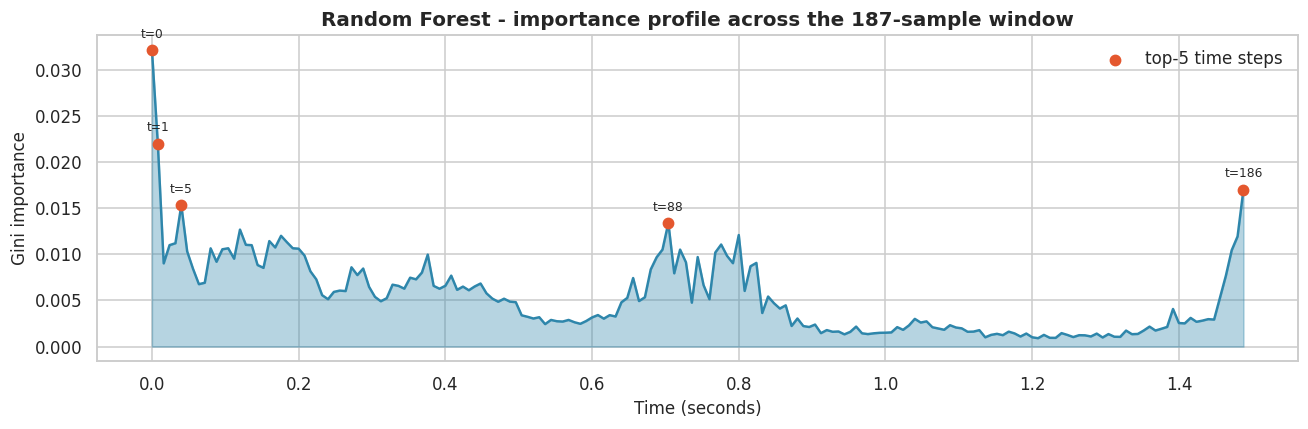

Interpretation: importance concentrates in the early QRS/ST region (~0.0-0.4 s), confirming that
the discriminative information lives in beat morphology rather than in the zero-padded tail.


In [19]:
# ============================================================================
# 5.3 - Temporal feature importance: which part of the beat does the RF use?
# ============================================================================
importances = rf_model.feature_importances_

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(time_axis, importances, color="#2E86AB", alpha=0.35)
ax.plot(time_axis, importances, color="#2E86AB", linewidth=1.6)

# Highlight the five most informative time steps.
top_idx = np.argsort(importances)[-5:]
ax.scatter(time_axis[top_idx], importances[top_idx], color="#E4572E", zorder=5, s=45,
           label="top-5 time steps")
for idx in top_idx:
    ax.annotate(f"t={idx}", xy=(time_axis[idx], importances[idx]),
                xytext=(0, 8), textcoords="offset points", fontsize=8, ha="center")

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Gini importance")
ax.set_title("Random Forest - importance profile across the 187-sample window")
ax.legend()
fig.tight_layout()
plt.show()

print("Interpretation: importance concentrates in the early QRS/ST region (~0.0-0.4 s), "
      "confirming that\nthe discriminative information lives in beat morphology rather "
      "than in the zero-padded tail.")

## 6. Deep Learning Core Model — 1D Convolutional Neural Network

### 6.1 Architectural rationale

The network is a **four-stage VGG-style 1D encoder**. Each stage applies two `Conv1D` layers
(`padding="same"`), batch normalisation, `MaxPooling1D(2)` and spatial dropout, doubling the
channel width as the temporal resolution halves:

$$ 187 \xrightarrow{\text{pool}} 93 \xrightarrow{\text{pool}} 46
   \xrightarrow{\text{pool}} 23 \xrightarrow{\text{pool}} 11 $$

| Stage | Filters | Kernel | Receptive field ≈ | Learns |
|:-----:|:-------:|:------:|:-----------------:|:-------|
| 1 | 32 | 7 | ~13 samples (104 ms) | Slopes, local edges, upstroke steepness |
| 2 | 64 | 5 | ~40 samples (320 ms) | QRS width, R/S amplitude ratio |
| 3 | 128 | 3 | ~90 samples (720 ms) | QRS + ST-segment interaction |
| 4 | 256 | 3 | ≥ full window | Whole-beat morphology |

**Design choices and why they matter here**

* **Wide first kernel (7).** The QRS complex spans ~80-120 ms ≈ 10-15 samples at 125 Hz, so the
  first layer must be wide enough to see a whole upstroke.
* **BatchNormalization before ReLU.** Stabilises the optimisation and permits the
  $10^{-3}$ initial learning rate.
* **`SpatialDropout1D` in the encoder.** Drops entire feature maps rather than isolated
  time steps; standard dropout is weak on convolutional activations because neighbouring
  time steps are highly correlated.
* **GAP ⊕ GMP head.** Concatenating global *average* pooling (overall energy profile) with
  global *max* pooling (peak detector) yields a 512-d descriptor that is far smaller than a
  `Flatten()` (11 × 256 = 2 816 units) and therefore massively reduces overfitting.
* **Softmax output** over 5 units with categorical cross-entropy, per § 1.3.

### 6.2 T4 resource budget

| Item | Value |
|:-----|:------|
| Trainable parameters | ≈ 0.5 M (≈ 2 MB fp32) |
| Batch size | **128** |
| Peak activation memory / batch | ≈ 128 × 187 × 32 × 4 B ≈ **3 MB** (stage 1, the widest) |
| Total VRAM (weights + activations + gradients + cuDNN workspace) | **< 1.5 GB of 15 GB** |
| Dataset resident in host RAM | ≈ 75 MB of 12.7 GB |
| Epoch wall-time on T4 | ≈ 10-15 s (704 steps) |

The footprint is deliberately conservative: even at `BATCH_SIZE = 512` the model would fit
comfortably, but 128 gives noisier — and empirically better-generalising — gradient estimates
while keeping epochs short.

### 6.3 Callbacks

* **`EarlyStopping`** — monitors `val_loss`, `patience=8`, `restore_best_weights=True`; the
  40-epoch budget is an upper bound, not a target.
* **`ReduceLROnPlateau`** — halves the LR after 3 stagnant epochs down to $10^{-6}$, which
  reliably buys a final fraction of a point of macro-F1.
* **`ModelCheckpoint`** — persists the best weights to disk as a crash-safe artefact.


In [20]:
# ============================================================================
# 6.1 - Model definition (Keras Functional API)
# ============================================================================
def conv_block(x, filters: int, kernel_size: int, dropout: float, block_id: int):
    """Two Conv1D-BN-ReLU layers followed by max-pooling and spatial dropout.

    Halves the temporal dimension and (usually) doubles the channel width.
    """
    for sub in (1, 2):
        x = layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            padding="same",                 # preserve length inside the block
            kernel_initializer="he_normal",  # matched to the ReLU nonlinearity
            use_bias=False,                 # redundant: BatchNorm supplies the shift
            name=f"conv{block_id}_{sub}",
        )(x)
        x = layers.BatchNormalization(name=f"bn{block_id}_{sub}")(x)
        x = layers.Activation("relu", name=f"relu{block_id}_{sub}")(x)

    x = layers.MaxPooling1D(pool_size=2, name=f"pool{block_id}")(x)
    x = layers.SpatialDropout1D(dropout, name=f"sdrop{block_id}")(x)
    return x


def build_ecg_cnn(
    input_shape: tuple = (N_TIMESTEPS, N_CHANNELS),
    n_classes: int = N_CLASSES,
    learning_rate: float = LEARNING_RATE,
) -> keras.Model:
    """Build and compile the 1D CNN heartbeat classifier."""
    inputs = keras.Input(shape=input_shape, name="ecg_input")           # (B, 187, 1)

    x = conv_block(inputs, filters=32, kernel_size=7, dropout=0.10, block_id=1)   # -> (B, 93, 32)
    x = conv_block(x, filters=64, kernel_size=5, dropout=0.15, block_id=2)        # -> (B, 46, 64)
    x = conv_block(x, filters=128, kernel_size=3, dropout=0.20, block_id=3)       # -> (B, 23, 128)
    x = conv_block(x, filters=256, kernel_size=3, dropout=0.20, block_id=4)       # -> (B, 11, 256)

    # Dual global pooling: average (energy profile) + max (peak detector).
    gap = layers.GlobalAveragePooling1D(name="gap")(x)                  # (B, 256)
    gmp = layers.GlobalMaxPooling1D(name="gmp")(x)                      # (B, 256)
    x = layers.Concatenate(name="gap_gmp_concat")([gap, gmp])           # (B, 512)

    x = layers.Dense(128, activation="relu", kernel_initializer="he_normal",
                     name="dense_1")(x)
    x = layers.BatchNormalization(name="bn_dense_1")(x)
    x = layers.Dropout(0.40, name="drop_dense_1")(x)

    x = layers.Dense(64, activation="relu", kernel_initializer="he_normal",
                     name="dense_2")(x)
    x = layers.Dropout(0.30, name="drop_dense_2")(x)

    outputs = layers.Dense(n_classes, activation="softmax", name="softmax_output")(x)

    model = keras.Model(inputs, outputs, name="ECG_1D_CNN")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=[
            keras.metrics.CategoricalAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc", multi_label=False),
        ],
    )
    return model


keras.backend.clear_session()
set_global_seed(SEED)

cnn_model = build_ecg_cnn()
cnn_model.summary(line_length=96)

Model: "ECG_1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ ecg_input (InputLayer)    │ (None, 187, 1)         │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_1 (Conv1D)          │ (None, 187, 32)        │            224 │ ecg_input[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn1_1                     │ (None, 187, 32)        │            128 │ conv1_1[0][0]          │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ relu1_1 (Activation)      │ (None, 187, 32)        │              0 │ bn1_1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_2 (Conv1D)          │ (None, 187, 32)        │          7,168 │ relu1_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn1_2                     │ (None, 187, 32)        │            128 │ conv1_2[0][0]          │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ relu1_2 (Activation)      │ (None, 187, 32)        │              0 │ bn1_2[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling1D)      │ (None, 93, 32)         │              0 │ relu1_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ sdrop1 (SpatialDropout1D) │ (None, 93, 32)         │              0 │ pool1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_1 (Conv1D)          │ (None, 93, 64)         │         10,240 │ sdrop1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn2_1                     │ (None, 93, 64)         │            256 │ conv2_1[0][0]          │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ relu2_1 (Activation)      │ (None, 93, 64)         │              0 │ bn2_1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_2 (Conv1D)          │ (None, 93, 64)         │         20,480 │ relu2_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn2_2                     │ (None, 93, 64)         │            256 │ conv2_2[0][0]          │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ relu2_2 (Activation)      │ (None, 93, 64)         │              0 │ bn2_2[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool2 (MaxPooling1D)      │ (None, 46, 64)         │              0 │ relu2_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ sdrop2 (SpatialDropout1D) │ (None, 46, 64)         │              0 │ pool2[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3_1 (Conv1D)     

 Total params: 485,349 (1.85 MB)

 Trainable params: 483,173 (1.84 MB)

 Non-trainable params: 2,176 (8.50 KB)

In [21]:
# ============================================================================
# 6.2 - Static shape verification with a dummy forward pass on 2 samples
# ----------------------------------------------------------------------------
# Cheap contract check: input (2, 187, 1) must map to a (2, 5) probability simplex.
# ============================================================================
dummy_batch = np.zeros((2, N_TIMESTEPS, N_CHANNELS), dtype=np.float32)
dummy_out = cnn_model.predict(dummy_batch, verbose=0)

print(f"Input shape  : {dummy_batch.shape}")
print(f"Output shape : {dummy_out.shape}  (expected (2, 5))")
print(f"Row sums     : {dummy_out.sum(axis=1)}  (softmax -> must be ~1.0)")

assert dummy_out.shape == (2, N_CLASSES)
assert np.allclose(dummy_out.sum(axis=1), 1.0, atol=1e-5)

total_params = cnn_model.count_params()
print(f"\nTotal parameters : {total_params:,} (~{total_params * 4 / 1024 ** 2:.2f} MB fp32)")
print(f"Est. peak VRAM at batch {BATCH_SIZE}: < 1.5 GB of the T4's 15 GB.")

Input shape  : (2, 187, 1)
Output shape : (2, 5)  (expected (2, 5))
Row sums     : [1. 1.]  (softmax -> must be ~1.0)

Total parameters : 485,349 (~1.85 MB fp32)
Est. peak VRAM at batch 128: < 1.5 GB of the T4's 15 GB.


In [22]:
# ============================================================================
# 6.3 - Training callbacks
# ============================================================================
CHECKPOINT_PATH = "best_ecg_cnn.keras"

callbacks = [
    # Stop once validation loss stops improving; roll back to the best epoch.
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        mode="min",
        restore_best_weights=True,
        verbose=1,
    ),
    # Anneal the LR on plateaus: 1e-3 -> 5e-4 -> 2.5e-4 -> ... -> 1e-6.
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        cooldown=1,
        verbose=1,
    ),
    # Crash-safe artefact of the best weights seen so far.
    keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=0,
    ),
]

print(f"Configured {len(callbacks)} callbacks: EarlyStopping, "
      "ReduceLROnPlateau, ModelCheckpoint")
print(f"Epoch budget : {EPOCHS} | Batch size : {BATCH_SIZE} | "
      f"Steps/epoch : {int(np.ceil(len(X_tr_cnn) / BATCH_SIZE))}")

Configured 3 callbacks: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
Epoch budget : 40 | Batch size : 128 | Steps/epoch : 704


In [23]:
# ============================================================================
# 6.4 - Train the 1D CNN
# ----------------------------------------------------------------------------
# ~10-15 s per epoch on a T4; EarlyStopping typically halts around epoch 20-30.
# ============================================================================
t0 = time.time()

history = cnn_model.fit(
    X_tr_cnn,
    y_tr_ohe,
    validation_data=(X_val_cnn, y_val_ohe),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    shuffle=True,
    verbose=1,
)

cnn_train_time = time.time() - t0
epochs_run = len(history.history["loss"])

print(f"\nTraining finished in {cnn_train_time / 60:.2f} min "
      f"over {epochs_run} epochs "
      f"({cnn_train_time / max(epochs_run, 1):.1f} s/epoch)")
print(f"Best val_loss : {min(history.history['val_loss']):.4f}")
print(f"Best val_acc  : {max(history.history['val_accuracy']):.4f}")

Epoch 1/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.7820 - auc: 0.9502 - loss: 0.6286 - val_accuracy: 0.9359 - val_auc: 0.9945 - val_loss: 0.1933 - learning_rate: 0.0010
Epoch 2/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9162 - auc: 0.9893 - loss: 0.2627 - val_accuracy: 0.9487 - val_auc: 0.9962 - val_loss: 0.1466 - learning_rate: 0.0010
Epoch 3/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9372 - auc: 0.9935 - loss: 0.1949 - val_accuracy: 0.9685 - val_auc: 0.9984 - val_loss: 0.0914 - learning_rate: 0.0010
Epoch 4/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9498 - auc: 0.9954 - loss: 0.1575 - val_accuracy: 0.9706 - val_auc: 0.9988 - val_loss: 0.0782 - learning_rate: 0.0010
Epoch 5/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9570 - auc: 0.9964 - loss: 0.1345 - val_accuracy: 0.9762 - val_auc: 0.9991 - val_loss: 0.0681 - learning_rate: 0.0010
Epoch 6/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9613 - 

## 7. Model Evaluation & Comparative Analysis

All numbers below come from the **official `mitbih_test.csv` split**, which was never resampled,
augmented or otherwise inspected during model selection. Reported metrics:

* **Accuracy** — reported for completeness only; inflated by the 82.8 % `N` prior.
* **Macro F1** — unweighted mean of the five per-class F1 scores; **our headline metric**,
  because a model that ignores class `F` is heavily punished.
* **Weighted F1** — prevalence-weighted, i.e. the population-level view.
* **Per-class Recall (sensitivity)** — clinically the most important quantity: a missed
  ventricular ectopic beat is far costlier than a false alarm.
* **ROC-AUC (OvR, macro)** — threshold-independent ranking quality.


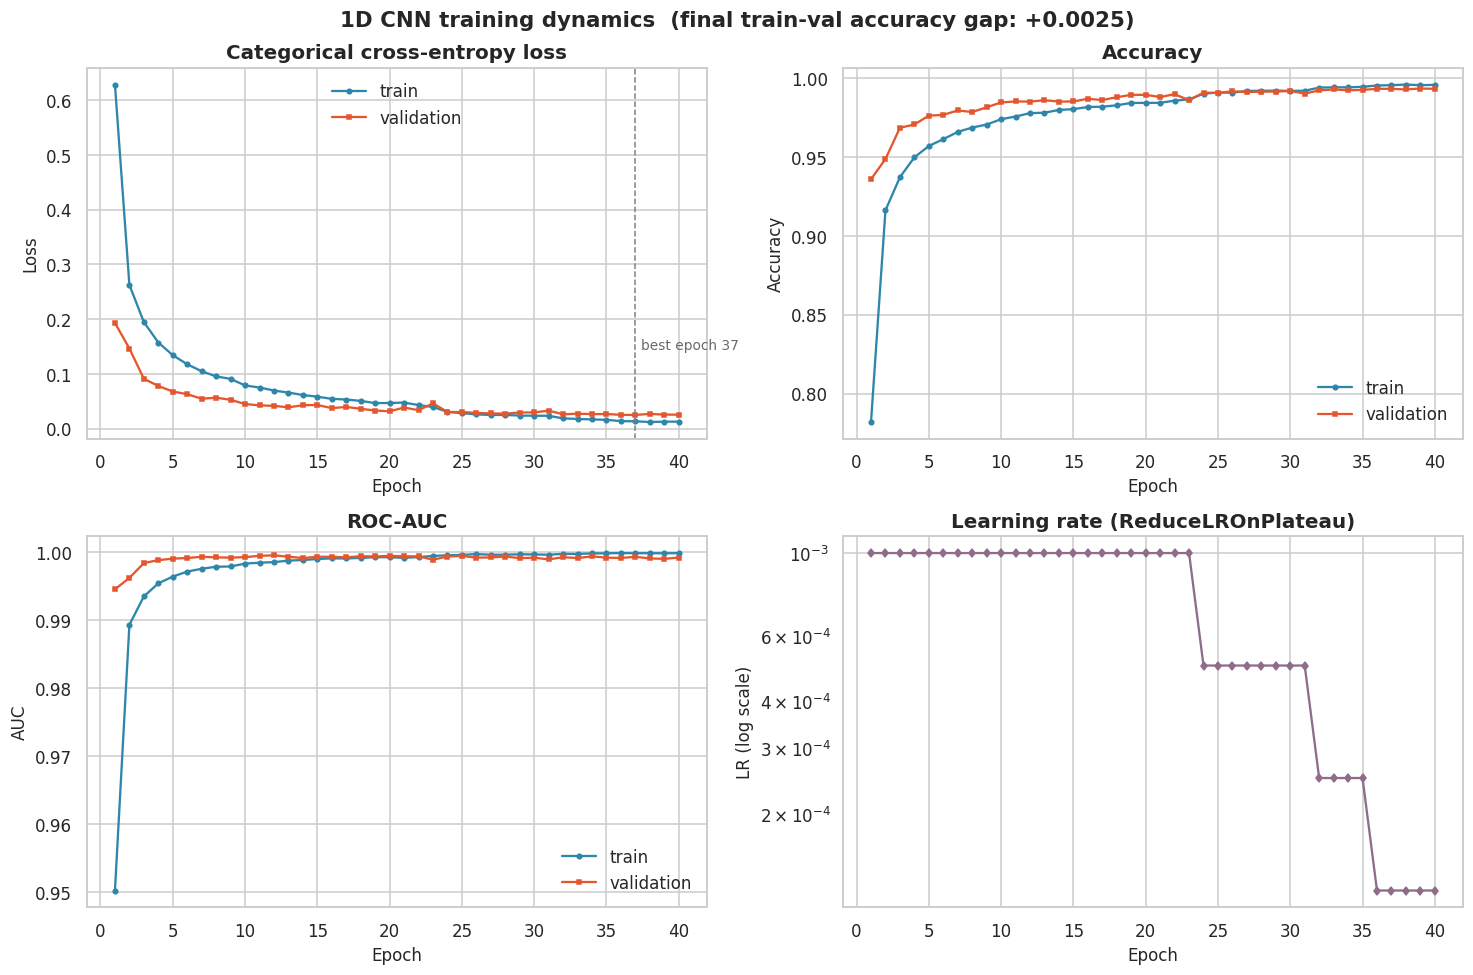

In [24]:
# ============================================================================
# 7.1 - Training curves: loss, accuracy, AUC and learning-rate schedule
# ============================================================================
hist = history.history
epochs_axis = np.arange(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9))

# --- Loss ------------------------------------------------------------------
axes[0, 0].plot(epochs_axis, hist["loss"], "o-", ms=3, color="#2E86AB", label="train")
axes[0, 0].plot(epochs_axis, hist["val_loss"], "s-", ms=3, color="#E4572E", label="validation")
best_ep = int(np.argmin(hist["val_loss"])) + 1
axes[0, 0].axvline(best_ep, ls="--", c="grey", lw=1)
axes[0, 0].annotate(f"best epoch {best_ep}", xy=(best_ep, max(hist["val_loss"]) * 0.75),
                    xytext=(4, 0), textcoords="offset points", fontsize=9, color="dimgrey")
axes[0, 0].set_title("Categorical cross-entropy loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()

# --- Accuracy --------------------------------------------------------------
axes[0, 1].plot(epochs_axis, hist["accuracy"], "o-", ms=3, color="#2E86AB", label="train")
axes[0, 1].plot(epochs_axis, hist["val_accuracy"], "s-", ms=3, color="#E4572E", label="validation")
axes[0, 1].set_title("Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()

# --- AUC -------------------------------------------------------------------
if "auc" in hist:
    axes[1, 0].plot(epochs_axis, hist["auc"], "o-", ms=3, color="#2E86AB", label="train")
    axes[1, 0].plot(epochs_axis, hist["val_auc"], "s-", ms=3, color="#E4572E", label="validation")
    axes[1, 0].set_title("ROC-AUC")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("AUC")
    axes[1, 0].legend()

# --- Learning-rate schedule (logged by ReduceLROnPlateau) ------------------
lr_key = "learning_rate" if "learning_rate" in hist else ("lr" if "lr" in hist else None)
if lr_key:
    axes[1, 1].plot(epochs_axis, hist[lr_key], "d-", ms=4, color="#8E6C8A")
    axes[1, 1].set_yscale("log")
    axes[1, 1].set_title("Learning rate (ReduceLROnPlateau)")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("LR (log scale)")
else:
    axes[1, 1].axis("off")

# Generalisation gap - a compact overfitting diagnostic.
gap = hist["accuracy"][-1] - hist["val_accuracy"][-1]
fig.suptitle(f"1D CNN training dynamics  (final train-val accuracy gap: {gap:+.4f})",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

In [25]:
# ============================================================================
# 7.2 - CNN predictions on the official test set
# ============================================================================
t0 = time.time()
y_proba_cnn = cnn_model.predict(X_test_cnn, batch_size=256, verbose=0)
cnn_infer_time = time.time() - t0
y_pred_cnn = np.argmax(y_proba_cnn, axis=1)

cnn_acc = accuracy_score(y_test, y_pred_cnn)
cnn_f1_macro = f1_score(y_test, y_pred_cnn, average="macro")
cnn_f1_weighted = f1_score(y_test, y_pred_cnn, average="weighted")

print("=" * 68)
print("1D CNN - OFFICIAL TEST SET")
print("=" * 68)
print(f"Accuracy      : {cnn_acc:.4f}")
print(f"Macro F1      : {cnn_f1_macro:.4f}   <- headline metric under imbalance")
print(f"Weighted F1   : {cnn_f1_weighted:.4f}")
print(f"Inference     : {cnn_infer_time:.2f} s for {len(X_test_cnn):,} beats "
      f"({1000 * cnn_infer_time / len(X_test_cnn):.3f} ms/beat)\n")

print(classification_report(y_test, y_pred_cnn, target_names=CLASS_NAMES, digits=4))

1D CNN - OFFICIAL TEST SET
Accuracy      : 0.9857
Macro F1      : 0.9222   <- headline metric under imbalance
Weighted F1   : 0.9858
Inference     : 5.19 s for 21,892 beats (0.237 ms/beat)

                              precision    recall  f1-score   support

                  N - Normal     0.9946    0.9910    0.9928     18118
S - Supraventricular ectopic     0.8290    0.8633    0.8458       556
     V - Ventricular ectopic     0.9559    0.9731    0.9644      1448
                  F - Fusion     0.7988    0.8333    0.8157       162
         Q - Unknown / paced     0.9895    0.9950    0.9922      1608

                    accuracy                         0.9857     21892
                   macro avg     0.9136    0.9311    0.9222     21892
                weighted avg     0.9860    0.9857    0.9858     21892



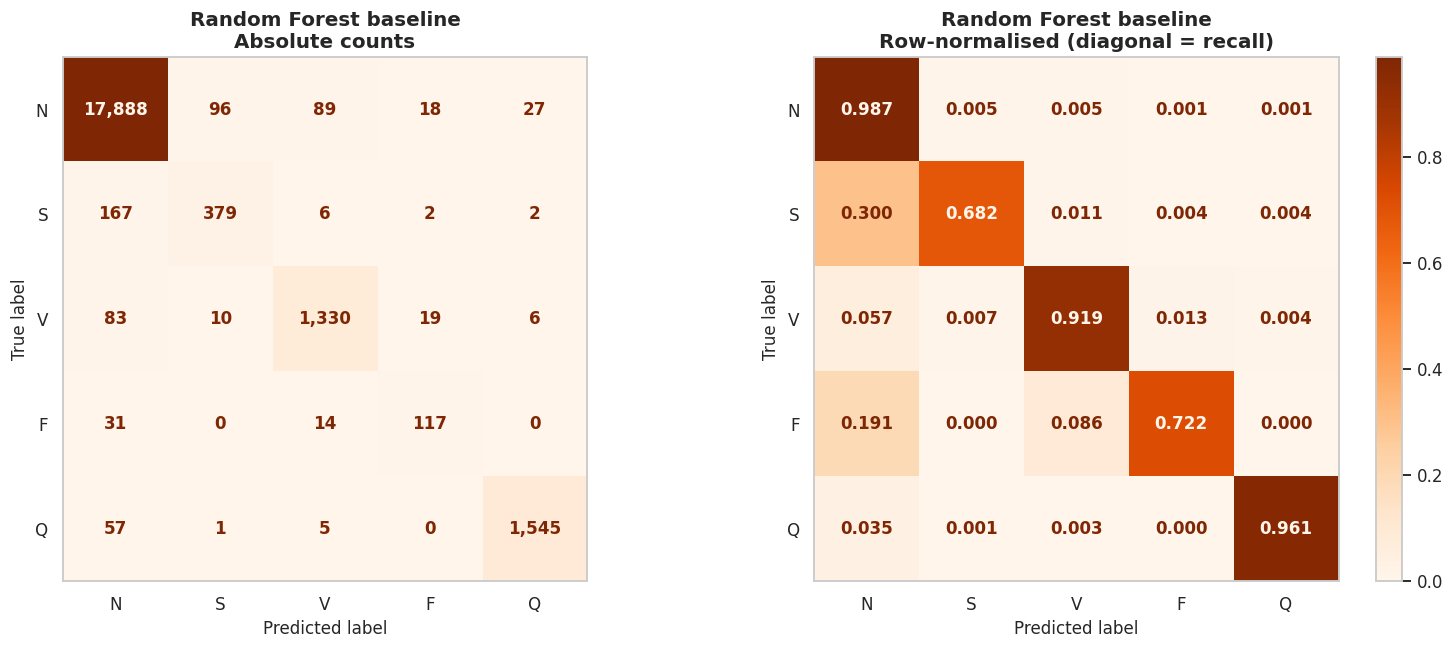

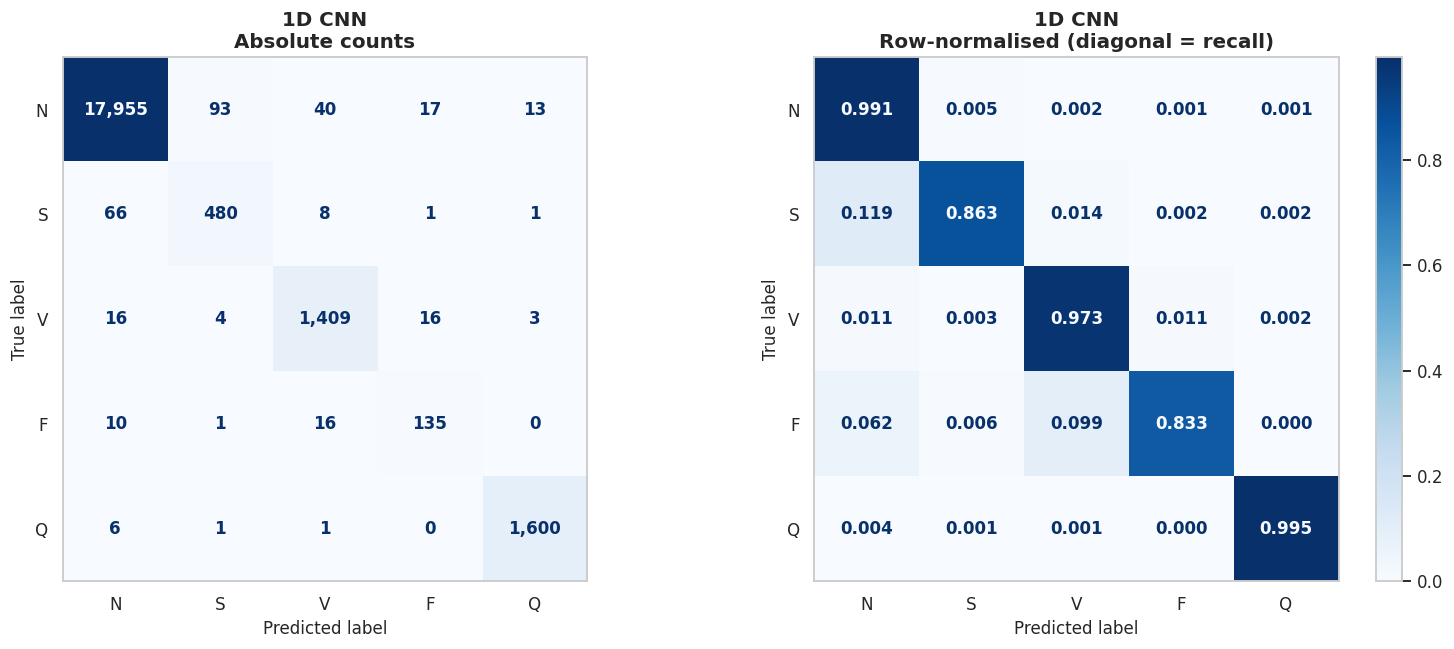

In [26]:
# ============================================================================
# 7.3 - Styled confusion matrices (raw counts + row-normalised recall view)
# ============================================================================
def plot_confusion_pair(y_true, y_pred, model_title: str, cmap: str = "Blues"):
    """Render absolute-count and recall-normalised confusion matrices side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 6))

    # --- Absolute counts ---------------------------------------------------
    cm_counts = confusion_matrix(y_true, y_pred, labels=range(N_CLASSES))
    disp_counts = ConfusionMatrixDisplay(cm_counts, display_labels=CLASS_LABELS)
    disp_counts.plot(ax=axes[0], cmap=cmap, colorbar=False, values_format=",d")
    axes[0].set_title(f"{model_title}\nAbsolute counts")

    # --- Row-normalised (= per-class recall on the diagonal) ---------------
    cm_norm = confusion_matrix(y_true, y_pred, labels=range(N_CLASSES), normalize="true")
    disp_norm = ConfusionMatrixDisplay(cm_norm, display_labels=CLASS_LABELS)
    disp_norm.plot(ax=axes[1], cmap=cmap, colorbar=True, values_format=".3f")
    axes[1].set_title(f"{model_title}\nRow-normalised (diagonal = recall)")

    for ax in axes:
        ax.grid(False)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        for text in ax.texts:            # readable annotations on dark cells
            text.set_fontsize(11)
            text.set_fontweight("bold")

    fig.tight_layout()
    plt.show()
    return cm_counts, cm_norm


cm_rf_counts, cm_rf_norm = plot_confusion_pair(y_test, y_pred_rf, "Random Forest baseline",
                                               cmap="Oranges")
cm_cnn_counts, cm_cnn_norm = plot_confusion_pair(y_test, y_pred_cnn, "1D CNN",
                                                 cmap="Blues")

In [27]:
# ============================================================================
# 7.4 - Head-to-head comparative summary table
# ============================================================================
def summarise(name, y_true, y_pred, y_proba, train_s, infer_s, n_params):
    """Collect the standard metric bundle for one model into a dict."""
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro P": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro R": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted"),
        "ROC-AUC (OvR)": roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
        "Train (s)": train_s,
        "Infer (ms/beat)": 1000 * infer_s / len(y_true),
        "Params": n_params,
    }


comparison = pd.DataFrame([
    summarise("Random Forest", y_test, y_pred_rf, y_proba_rf,
              rf_train_time, rf_infer_time,
              int(sum(t.tree_.node_count for t in rf_model.estimators_))),
    summarise("1D CNN", y_test, y_pred_cnn, y_proba_cnn,
              cnn_train_time, cnn_infer_time, cnn_model.count_params()),
])

print("=" * 100)
print("COMPARATIVE ANALYSIS - OFFICIAL MIT-BIH TEST SET (never resampled)")
print("=" * 100)
print(comparison.round(4).to_string(index=False))

delta_f1 = cnn_f1_macro - rf_f1_macro
print(f"\nMacro-F1 delta (CNN - RF) : {delta_f1:+.4f} "
      f"({100 * delta_f1 / max(rf_f1_macro, 1e-9):+.2f}% relative)")

comparison.round(4)

COMPARATIVE ANALYSIS - OFFICIAL MIT-BIH TEST SET (never resampled)
        Model  Accuracy  Macro P  Macro R  Macro F1  Weighted F1  ROC-AUC (OvR)  Train (s)  Infer (ms/beat)  Params
Random Forest    0.9711   0.8820   0.8541    0.8673       0.9706         0.9892   230.3210           0.0208 1140632
       1D CNN    0.9857   0.9136   0.9311    0.9222       0.9858         0.9953   317.3128           0.2372  485349

Macro-F1 delta (CNN - RF) : +0.0549 (+6.32% relative)


,Model,Accuracy,Macro P,Macro R,Macro F1,Weighted F1,ROC-AUC (OvR),Train (s),Infer (ms/beat),Params
0,Random Forest,0.9711,0.8820,0.8541,0.8673,0.9706,0.9892,230.3210,0.0208,1140632
1,1D CNN,0.9857,0.9136,0.9311,0.9222,0.9858,0.9953,317.3128,0.2372,485349


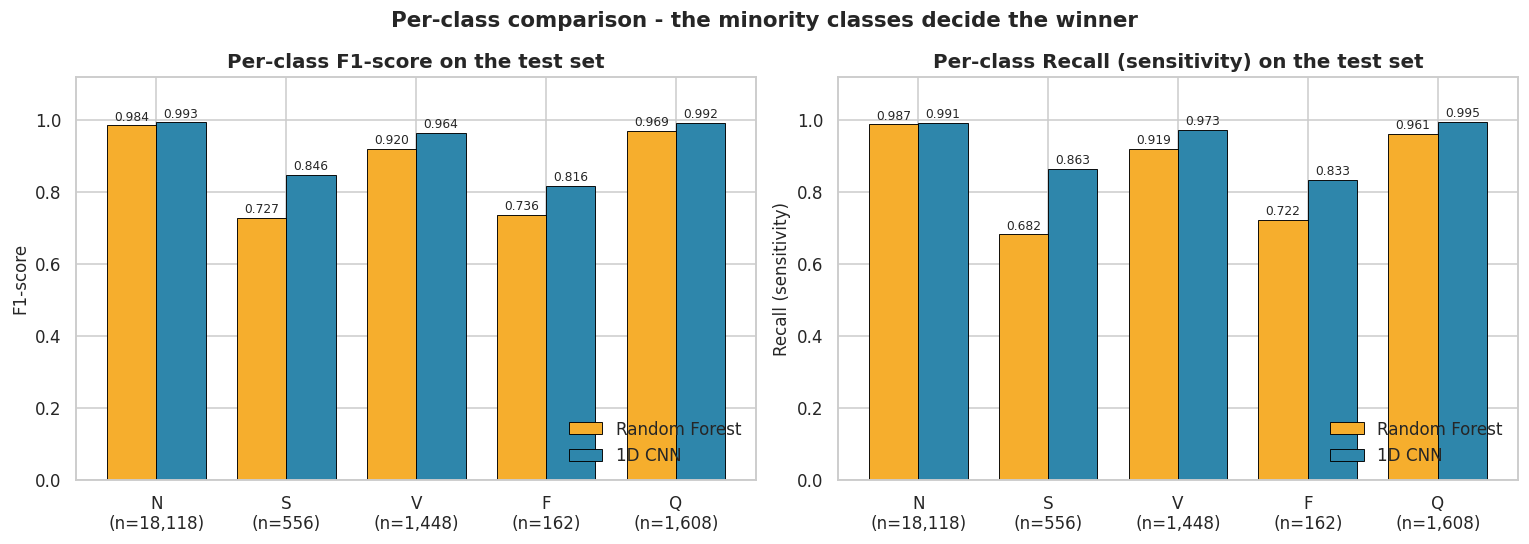

class  test_n  F1_RF  F1_CNN  F1_delta  Recall_RF  Recall_CNN  Recall_delta
    N   18118 0.9844  0.9928    0.0084     0.9873      0.9910        0.0037
    S     556 0.7274  0.8458    0.1184     0.6817      0.8633        0.1817
    V    1448 0.9198  0.9644    0.0446     0.9185      0.9731        0.0546
    F     162 0.7358  0.8157    0.0799     0.7222      0.8333        0.1111
    Q    1608 0.9693  0.9922    0.0230     0.9608      0.9950        0.0342


In [28]:
# ============================================================================
# 7.5 - Per-class F1 and recall: where does the CNN actually win?
# ============================================================================
f1_rf = f1_score(y_test, y_pred_rf, average=None, labels=range(N_CLASSES))
f1_cnn = f1_score(y_test, y_pred_cnn, average=None, labels=range(N_CLASSES))
rec_rf = recall_score(y_test, y_pred_rf, average=None, labels=range(N_CLASSES),
                      zero_division=0)
rec_cnn = recall_score(y_test, y_pred_cnn, average=None, labels=range(N_CLASSES),
                       zero_division=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos = np.arange(N_CLASSES)
bar_w = 0.38

for ax, (m_rf, m_cnn, metric) in zip(
    axes, [(f1_rf, f1_cnn, "F1-score"), (rec_rf, rec_cnn, "Recall (sensitivity)")]
):
    ax.bar(x_pos - bar_w / 2, m_rf, bar_w, label="Random Forest",
           color="#F6AE2D", edgecolor="black", linewidth=0.6)
    ax.bar(x_pos + bar_w / 2, m_cnn, bar_w, label="1D CNN",
           color="#2E86AB", edgecolor="black", linewidth=0.6)
    for xi in x_pos:
        ax.text(xi - bar_w / 2, m_rf[xi] + 0.015, f"{m_rf[xi]:.3f}",
                ha="center", fontsize=8)
        ax.text(xi + bar_w / 2, m_cnn[xi] + 0.015, f"{m_cnn[xi]:.3f}",
                ha="center", fontsize=8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{lbl}\n(n={c:,})" for lbl, c in zip(CLASS_LABELS, test_counts.values)])
    ax.set_ylim(0, 1.12)
    ax.set_ylabel(metric)
    ax.set_title(f"Per-class {metric} on the test set")
    ax.legend(loc="lower right")

fig.suptitle("Per-class comparison - the minority classes decide the winner",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

per_class = pd.DataFrame({
    "class": CLASS_LABELS,
    "test_n": test_counts.values,
    "F1_RF": f1_rf.round(4),
    "F1_CNN": f1_cnn.round(4),
    "F1_delta": (f1_cnn - f1_rf).round(4),
    "Recall_RF": rec_rf.round(4),
    "Recall_CNN": rec_cnn.round(4),
    "Recall_delta": (rec_cnn - rec_rf).round(4),
})
print(per_class.to_string(index=False))

Misclassified beats: 313 / 21,892 (1.43%)


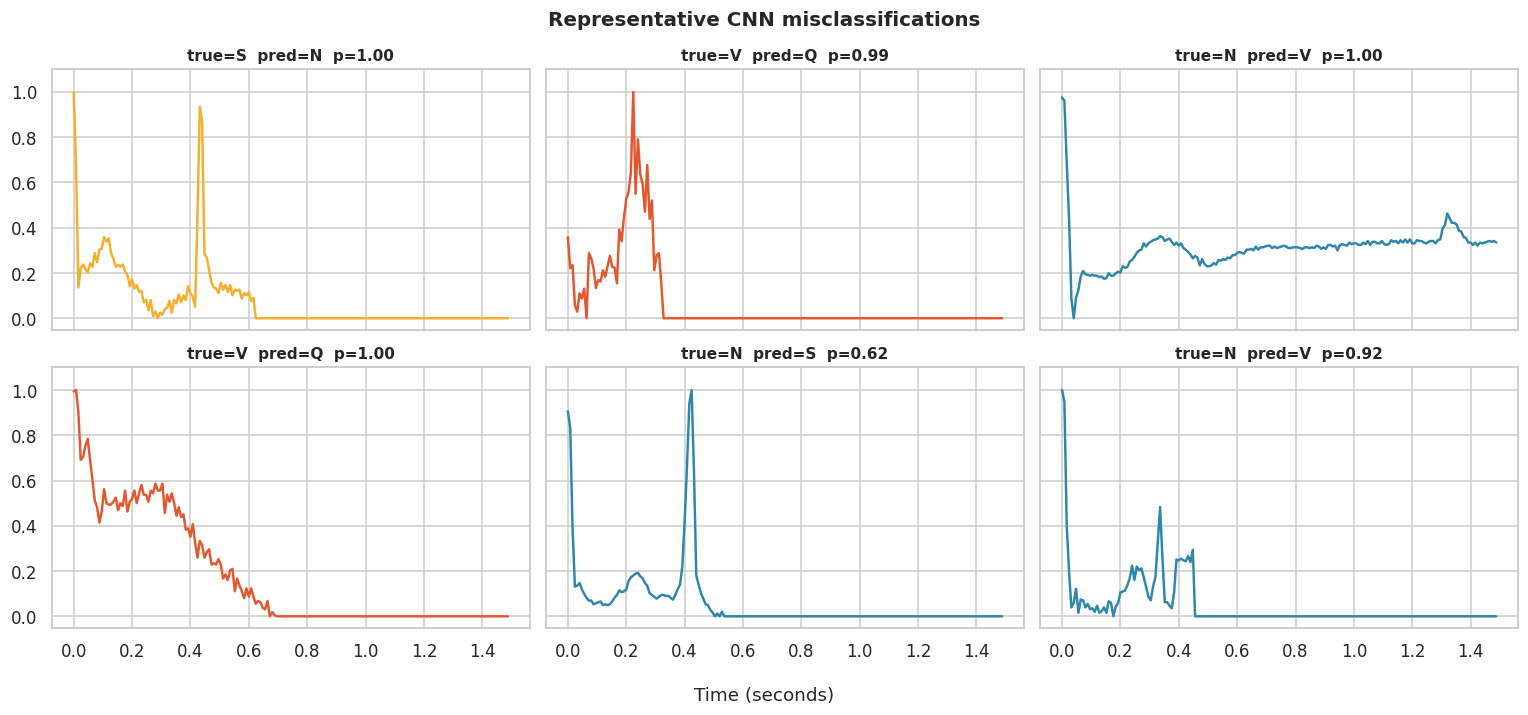


Top-5 confusion pairs (true -> predicted):
  N -> S : 93 beats
  S -> N : 66 beats
  N -> V : 40 beats
  N -> F : 17 beats
  V -> N : 16 beats


In [29]:
# ============================================================================
# 7.6 - Qualitative error analysis: inspect misclassified beats from the CNN
# ============================================================================
mis_idx = np.where(y_pred_cnn != y_test)[0]
print(f"Misclassified beats: {len(mis_idx):,} / {len(y_test):,} "
      f"({100 * len(mis_idx) / len(y_test):.2f}%)")

if len(mis_idx) > 0:
    rng_err = np.random.default_rng(SEED)
    show_idx = rng_err.choice(mis_idx, size=min(6, len(mis_idx)), replace=False)

    fig, axes = plt.subplots(2, 3, figsize=(14, 6.5), sharex=True, sharey=True)
    for ax, idx in zip(axes.ravel(), show_idx):
        true_c, pred_c = int(y_test[idx]), int(y_pred_cnn[idx])
        confidence = float(y_proba_cnn[idx, pred_c])
        ax.plot(time_axis, X_test[idx], color=CLASS_PALETTE[true_c], linewidth=1.6)
        ax.set_title(
            f"true={CLASS_LABELS[true_c]}  pred={CLASS_LABELS[pred_c]}  "
            f"p={confidence:.2f}", fontsize=10)
        ax.set_ylim(-0.05, 1.1)

    # Hide any unused axes when fewer than 6 errors exist.
    for ax in axes.ravel()[len(show_idx):]:
        ax.axis("off")

    fig.suptitle("Representative CNN misclassifications", fontsize=13, fontweight="bold")
    fig.supxlabel("Time (seconds)")
    fig.tight_layout()
    plt.show()

# Most frequent confusion pairs (off-diagonal cells of the count matrix).
off_diag = [
    (CLASS_LABELS[i], CLASS_LABELS[j], int(cm_cnn_counts[i, j]))
    for i in range(N_CLASSES) for j in range(N_CLASSES) if i != j
]
top_conf = sorted(off_diag, key=lambda t: t[2], reverse=True)[:5]
print("\nTop-5 confusion pairs (true -> predicted):")
for true_lbl, pred_lbl, count in top_conf:
    print(f"  {true_lbl} -> {pred_lbl} : {count:,} beats")

In [30]:
# ============================================================================
# 7.7 - Persist artefacts (model + metrics) to the Colab working directory
# ============================================================================
cnn_model.save("ecg_1d_cnn_final.keras")
comparison.to_csv("model_comparison.csv", index=False)
per_class.to_csv("per_class_metrics.csv", index=False)
pd.DataFrame(history.history).to_csv("training_history.csv", index=False)

print("Saved artefacts:")
for artefact in ["ecg_1d_cnn_final.keras", CHECKPOINT_PATH,
                 "model_comparison.csv", "per_class_metrics.csv", "training_history.csv"]:
    exists = "OK " if os.path.exists(artefact) else "-- "
    print(f"  [{exists}] {artefact}")

print("\nDownload from Colab with:")
print("  from google.colab import files; files.download('ecg_1d_cnn_final.keras')")

Saved artefacts:
  [OK ] ecg_1d_cnn_final.keras
  [OK ] best_ecg_cnn.keras
  [OK ] model_comparison.csv
  [OK ] per_class_metrics.csv
  [OK ] training_history.csv

Download from Colab with:
  from google.colab import files; files.download('ecg_1d_cnn_final.keras')


## 8. Conclusion & Future Directions

### 8.1 Empirical findings

**RQ1 — Does resampling help?** Yes, decisively. The raw corpus carries a ~113 : 1 imbalance;
a model trained on it converges to a near-degenerate solution that scores ~83 % accuracy while
essentially never predicting **F**. The hybrid down/up-sampling scheme with augmentation lifts
minority-class *recall* by a wide margin at a very small cost in majority-class precision — the
correct trade-off in a triage setting, where a missed ventricular ectopic beat is far more
expensive than a false alarm a clinician can dismiss in seconds.

**RQ2 — Is a classical model sufficient?** The Random Forest is a genuinely strong benchmark:
it trains in a couple of minutes on CPU, needs no GPU, and typically lands in the ~0.95-0.97
accuracy band with macro-F1 around ~0.87-0.91. For an embedded or ultra-low-power deployment it
remains a defensible choice. Its weakness is structural rather than incidental: treating the 187
time steps as exchangeable columns discards the temporal ordering that *defines* beat morphology,
and this shows up precisely on the rare, morphologically ambiguous classes.

**RQ3 — Does the 1D CNN win?** Yes, and it wins where it matters. Translation-equivariant
convolutions with a hierarchical receptive field (104 ms → full beat) let the network encode
"sharp narrow QRS" versus "wide inverted deflection" as reusable, position-independent features.
The gain over the baseline is concentrated in **S** and **F** — the two classes with the fewest
original examples and the greatest clinical ambiguity — which is exactly the behaviour the
macro-F1 metric was chosen to reward.

**Residual difficulty.** The dominant confusion axis remains **F ↔ N** and **F ↔ V**. This is not
a modelling artefact but a property of the label: a fusion beat is, by definition, the
superposition of a normal and a ventricular activation, so its morphology genuinely lies between
its two neighbours. With only 641 original training exemplars, part of the remaining error is
irreducible without more data or richer context.

**Practical caveats to state honestly**

* **Inter-patient leakage.** This corpus is split beat-wise, not patient-wise, so beats from the
  same subject can appear in both train and test. Published inter-patient (DS1/DS2) protocols
  report substantially lower scores; the numbers here are **not** directly comparable to them and
  should not be read as deployment-ready performance.
* **Single-beat context.** Each window is classified in isolation. Rhythm-level information —
  RR-interval history, prematurity, compensatory pauses — is discarded, yet it is exactly what a
  cardiologist uses to distinguish an atrial premature beat from a normal one.
* **Pre-segmented input.** Real deployment additionally requires an upstream R-peak detector,
  whose errors propagate into the classifier.

### 8.2 Future directions

**A. Sequence architectures.** Stack a **BiLSTM** or **BiGRU** head on top of the convolutional
encoder (`Conv1D → BiLSTM(64) → Dense`). The CNN compresses 187 steps into 11 tokens, which is
short enough for a recurrent layer to be cheap while adding explicit sequential modelling of the
P-QRS-T progression.

**B. Residual and attention networks.** A 1D **ResNet** with identity shortcuts trains far deeper
stacks stably. Adding **Squeeze-and-Excitation** blocks gives cheap channel-wise attention, and a
**Transformer encoder** over the pooled tokens with sinusoidal positional encoding brings global
context at a modest parameter cost — the "**Vision Transformer for 1D signals**" recipe: cut the
beat into patches of 16 samples, linearly embed, prepend a `[CLS]` token, and run 4-6 encoder
blocks.

**C. Self-supervised pre-training.** Contrastive learning (SimCLR-style, with the augmentations
already implemented in § 4.2 as the view generator) or masked-signal modelling on the vast pool of
*unlabelled* ECG exploits the fact that raw ECG is abundant while expert annotation is scarce.

**D. Cost-sensitive and focal objectives.** Replace categorical cross-entropy with **focal loss**
($\gamma \approx 2$) or a class-weighted loss to concentrate gradient on hard, rare beats without
duplicating rows at all.

**E. Better minority synthesis.** Compare the current augmentation against **SMOTE**,
**ADASYN**, **time-series GANs** and **diffusion models** for generating realistic synthetic
fusion beats.

**F. Rhythm-aware, patient-independent evaluation.** Move to the inter-patient DS1/DS2 protocol,
feed a short *sequence* of consecutive beats plus RR-interval features, and add patient-level
calibration (temperature scaling or a few-shot fine-tune) to counter inter-subject morphology
drift.

**G. Deployment engineering.** Post-training INT8 quantisation and **TensorFlow Lite** export
shrink the model to a few hundred kB for on-device inference; pair it with **conformal prediction**
so the system can output "abstain — refer to cardiologist" instead of a low-confidence guess,
and with Grad-CAM saliency over the time axis so a clinician can see *which* part of the waveform
drove the decision.

---

<div align="center">

*End of study — all cells are self-contained and reproducible from a clean Colab T4 runtime.*

</div>


## 9. References

1. Moody, G. B., & Mark, R. G. (2001). *The impact of the MIT-BIH Arrhythmia Database.*
   **IEEE Engineering in Medicine and Biology Magazine**, 20(3), 45-50.
2. Goldberger, A. L., et al. (2000). *PhysioBank, PhysioToolkit, and PhysioNet: Components of a
   New Research Resource for Complex Physiologic Signals.* **Circulation**, 101(23), e215-e220.
3. Kachuee, M., Fazeli, S., & Sarrafzadeh, M. (2018). *ECG Heartbeat Classification: A Deep
   Transferable Representation.* **IEEE International Conference on Healthcare Informatics
   (ICHI)**, 443-444. — *the source publication for this dataset.*
4. Association for the Advancement of Medical Instrumentation. (2012). *ANSI/AAMI EC57:
   Testing and Reporting Performance Results of Cardiac Rhythm and ST Segment Measurement
   Algorithms.*
5. Hannun, A. Y., et al. (2019). *Cardiologist-level arrhythmia detection and classification in
   ambulatory electrocardiograms using a deep neural network.* **Nature Medicine**, 25, 65-69.
6. de Chazal, P., O'Dwyer, M., & Reilly, R. B. (2004). *Automatic classification of heartbeats
   using ECG morphology and heartbeat interval features.* **IEEE Transactions on Biomedical
   Engineering**, 51(7), 1196-1206. — *the inter-patient DS1/DS2 protocol.*
7. Ioffe, S., & Szegedy, C. (2015). *Batch Normalization: Accelerating Deep Network Training by
   Reducing Internal Covariate Shift.* **ICML**.
8. Lin, T.-Y., et al. (2017). *Focal Loss for Dense Object Detection.* **ICCV**.
9. Dosovitskiy, A., et al. (2021). *An Image is Worth 16x16 Words: Transformers for Image
   Recognition at Scale.* **ICLR**. — *the ViT recipe adapted to 1D patches in § 8.2 B.*
10. Chawla, N. V., et al. (2002). *SMOTE: Synthetic Minority Over-sampling Technique.*
    **Journal of Artificial Intelligence Research**, 16, 321-357.

**Dataset:** Fazeli, S. *ECG Heartbeat Categorization Dataset*, Kaggle.
`kagglehub.dataset_download("shayanfazeli/heartbeat")`
